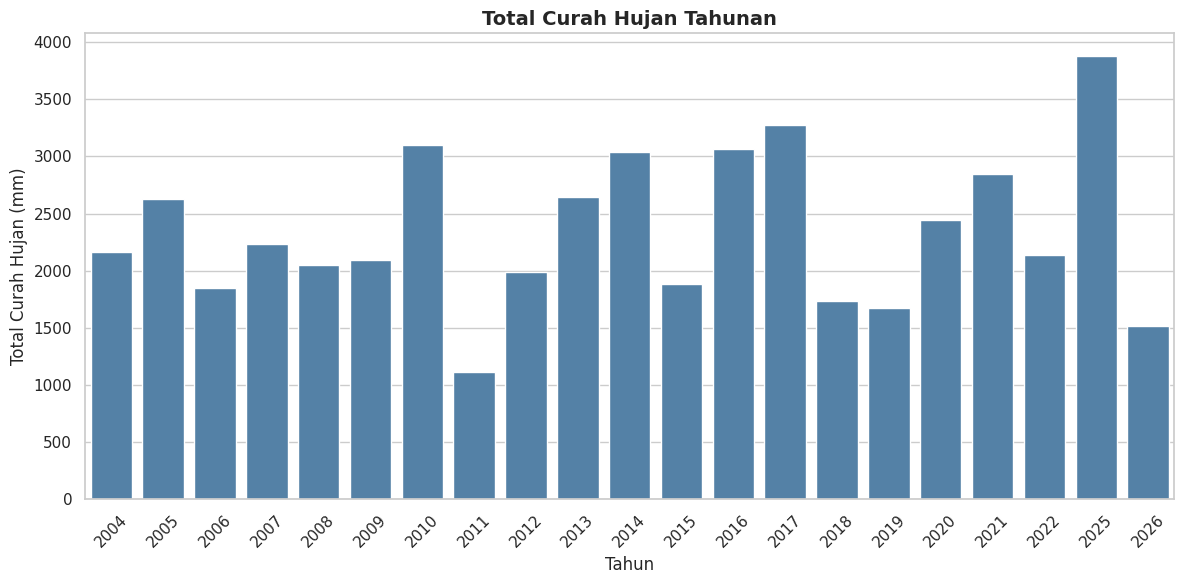

/tmp/ipykernel_2515/3658078967.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='Bulan', y='Curah Hujan (mm)', palette='Blues_r')


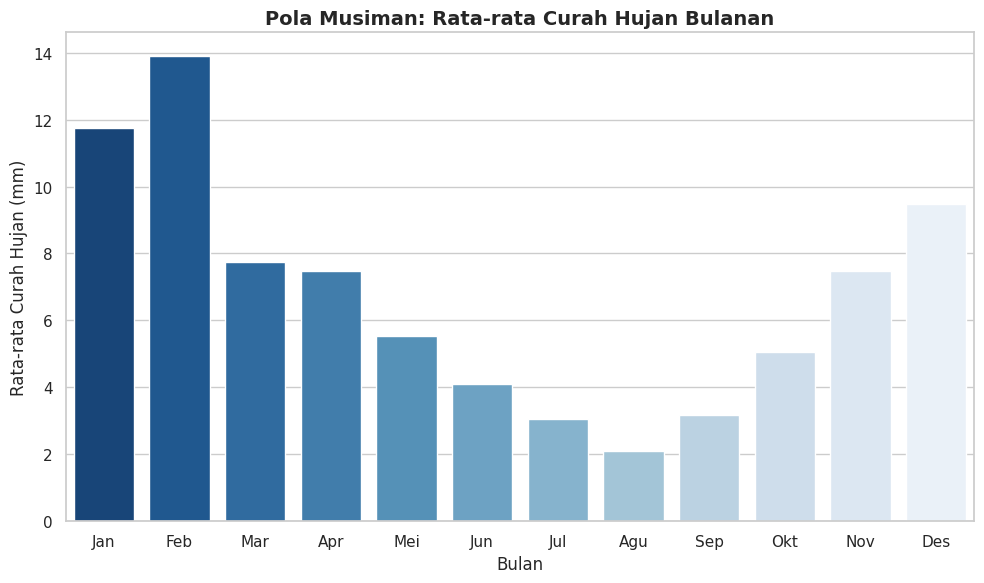

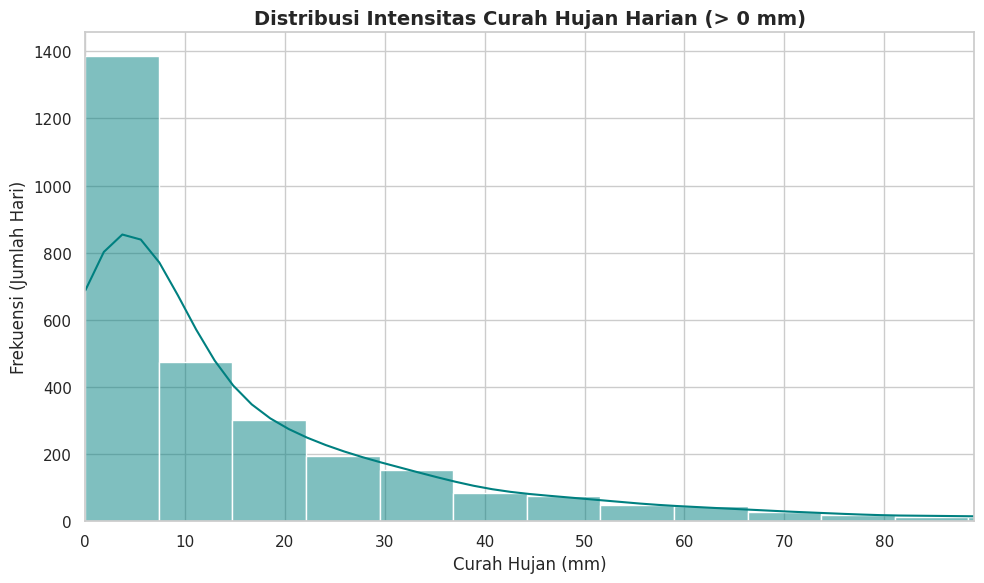

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# Gunakan sep=';' karena file disiapkan dengan format titik koma
df = pd.read_csv('Curah_Hujan.csv', sep=';')

# Ubah tipe data kolom Tanggal menjadi datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)

# Ekstrak Tahun dan Bulan untuk pengelompokan
df['Tahun'] = df['Tanggal'].dt.year
df['Bulan'] = df['Tanggal'].dt.month

# Atur gaya grafik (bisa diganti sesuai selera, misal 'darkgrid' atau 'ticks')
sns.set_theme(style="whitegrid")


# ==========================================
# GRAFIK 1: Total Curah Hujan per Tahun
# ==========================================
yearly_rainfall = df.groupby('Tahun')['Curah Hujan (mm)'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_rainfall, x='Tahun', y='Curah Hujan (mm)', color='steelblue')
plt.title('Total Curah Hujan Tahunan', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Curah Hujan (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================
# GRAFIK 2: Rata-rata Curah Hujan Bulanan
# ==========================================
monthly_avg = df.groupby('Bulan')['Curah Hujan (mm)'].mean().reset_index()

# Ubah angka bulan jadi nama bulan biar lebih rapi
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
monthly_avg['Bulan'] = monthly_avg['Bulan'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg, x='Bulan', y='Curah Hujan (mm)', palette='Blues_r')
plt.title('Pola Musiman: Rata-rata Curah Hujan Bulanan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Curah Hujan (mm)', fontsize=12)
plt.tight_layout()
plt.show()


# ==========================================
# GRAFIK 3: Distribusi Curah Hujan Harian
# ==========================================
# Kita buang hari yang cerah/kering (0 mm) agar grafik distribusinya tidak timpang
rainy_days = df[df['Curah Hujan (mm)'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(rainy_days['Curah Hujan (mm)'], bins=50, kde=True, color='teal')
plt.title('Distribusi Intensitas Curah Hujan Harian (> 0 mm)', fontsize=14, fontweight='bold')
plt.xlabel('Curah Hujan (mm)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Hari)', fontsize=12)

# Batasi sumbu X (misal ambil sampai persentil 98) agar pencilan (outlier) ekstrem tidak membuat grafik terlalu lebar
plt.xlim(0, rainy_days['Curah Hujan (mm)'].quantile(0.98))
plt.tight_layout()
plt.show()

/tmp/ipykernel_2515/1114487453.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=kategori_counts, x='Kategori Hujan', y='Jumlah Hari', palette='viridis')


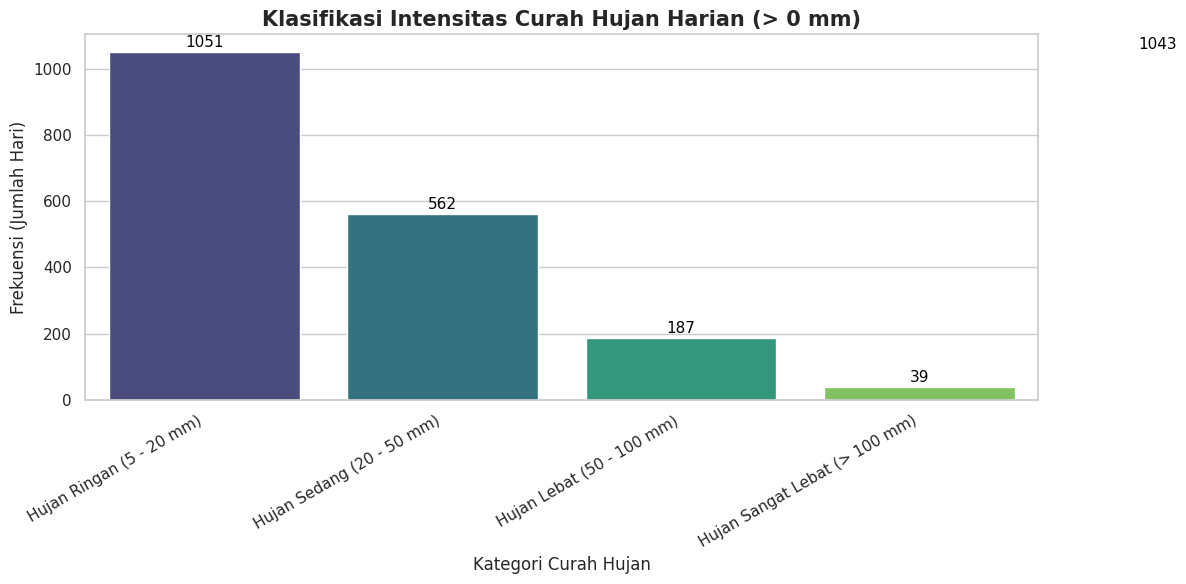

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Baca data
df = pd.read_csv('Curah_Hujan.csv', sep=';')

# 2. Buat fungsi klasifikasi berdasarkan standar yang diminta
def klasifikasi_hujan(ch):
    if pd.isna(ch):
        return np.nan
    elif ch == 0.0:
        return 'Tidak Hujan (0 mm)'
    elif 5 <= ch <= 20:
        return 'Hujan Ringan (5 - 20 mm)'
    elif 20 < ch <= 50:
        return 'Hujan Sedang (20 - 50 mm)'
    elif 50 < ch <= 100:
        return 'Hujan Lebat (50 - 100 mm)'
    elif ch > 100:
        return 'Hujan Sangat Lebat (> 100 mm)'
    else:
        return 'Tidak Terdefinisi'

# 3. Terapkan (apply) fungsi tersebut ke kolom Curah Hujan
df['Kategori Hujan'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

# (Opsional) Simpan ke file CSV baru
# df.to_csv('Curah_Hujan_Terklasifikasi.csv', index=False, sep=';')

# ==========================================
# GRAFIK DISTRIBUSI KELAS CURAH HUJAN
# ==========================================

# FILTER: Hanya ambil data yang nilai curah hujannya di atas 0
df_hujan = df[df['Curah Hujan (mm)'] > 0]

# Hitung total hari untuk masing-masing kategori (dari data yang sudah difilter)
kategori_counts = df_hujan['Kategori Hujan'].value_counts().reset_index()
kategori_counts.columns = ['Kategori Hujan', 'Jumlah Hari']

# Atur urutan kategori (Kelas 'Tidak Hujan' sudah dihapus dari daftar)
urutan = [
    'Hujan Ringan (5 - 20 mm)',
    'Hujan Sedang (20 - 50 mm)',
    'Hujan Lebat (50 - 100 mm)',
    'Hujan Sangat Lebat (> 100 mm)'
]

# Ubah tipe data kolom kategori menjadi Categorical agar urutannya mengunci
kategori_counts['Kategori Hujan'] = pd.Categorical(
    kategori_counts['Kategori Hujan'],
    categories=urutan,
    ordered=True
)
kategori_counts = kategori_counts.sort_values('Kategori Hujan')

# Set visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Buat bar chart
ax = sns.barplot(data=kategori_counts, x='Kategori Hujan', y='Jumlah Hari', palette='viridis')

plt.title('Klasifikasi Intensitas Curah Hujan Harian (> 0 mm)', fontsize=15, fontweight='bold')
plt.xlabel('Kategori Curah Hujan', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Hari)', fontsize=12)
plt.xticks(rotation=30, ha='right') # Putar tulisan di sumbu X agar tidak saling tabrak

# Tambahkan angka (label) tepat di atas setiap bar/batang
# Angka penambah (+ 15) disesuaikan agar teks tidak terlalu jauh dari puncak bar
for index, row in enumerate(kategori_counts['Jumlah Hari']):
    plt.text(index, row + 15, str(row), color='black', ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. PERSIAPAN DATA
# ==========================================
df = pd.read_csv('Curah_Hujan.csv', sep=';')

def klasifikasi_hujan(ch):
    if pd.isna(ch): return np.nan
    elif ch < 5: return 'Ringan/Tidak Hujan (< 5 mm)'
    elif 5 <= ch <= 20: return 'Hujan Ringan (5 - 20 mm)'
    elif 20 < ch <= 50: return 'Hujan Sedang (20 - 50 mm)'
    elif 50 < ch <= 100: return 'Hujan Lebat (50 - 100 mm)'
    else: return 'Hujan Sangat Lebat (> 100 mm)'

df['Kategori'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)
df = df.dropna()

label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Kategori'])

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

# ==========================================
# 2. SEQUENCE (Diubah jadi 14 Hari)
# ==========================================
# 14 hari ke belakang terbukti lebih optimal untuk tren cuaca lokal
time_steps = 14

X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. CLASS WEIGHTS (Dengan Softening)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)

# TRIK RAHASIA: Pelembutan bobot menggunakan akar kuadrat
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

print("\nBobot kelas setelah dilembutkan:")
for k, v in class_weights_dict.items():
    print(f"Kelas {label_encoder.inverse_transform([k])[0]}: {v:.2f}")

# ==========================================
# 4. ARSITEKTUR LSTM & OPTIMIZER CLIP
# ==========================================
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=len(kelas_unik), activation='softmax'))

# TRIK RAHASIA 2: Gradient Clipping (clipvalue=1.0) agar tidak meledak
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 5. CALLBACKS & TRAINING
# ==========================================
class TargetAkurasiCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        target_akurasi = 0.75
        akurasi_saat_ini = logs.get('val_accuracy')
        if akurasi_saat_ini is not None and akurasi_saat_ini >= target_akurasi:
            print(f"\n[INFO] Target tercapai! Akurasi validasi: {akurasi_saat_ini:.4f}")
            self.model.stop_training = True

callback_akurasi = TargetAkurasiCallback()
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)

print("\nMulai proses training (Maksimal 400 Epochs)...")
history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[callback_akurasi, reduce_lr, early_stop],
    verbose=1
)


Bobot kelas setelah dilembutkan:
Kelas Hujan Lebat (50 - 100 mm): 2.97
Kelas Hujan Ringan (5 - 20 mm): 1.21
Kelas Hujan Sangat Lebat (> 100 mm): 6.47
Kelas Hujan Sedang (20 - 50 mm): 1.64
Kelas Ringan/Tidak Hujan (< 5 mm): 0.51

Mulai proses training (Maksimal 400 Epochs)...
Epoch 1/400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7573 - loss: 1.0462 - val_accuracy: 0.6983 - val_loss: 1.0099 - learning_rate: 0.0010
Epoch 2/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7621 - loss: 1.0170 - val_accuracy: 0.6983 - val_loss: 1.0744 - learning_rate: 0.0010
Epoch 3/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7589 - loss: 1.0045 - val_accuracy: 0.6928 - val_loss: 1.0263 - learning_rate: 0.0010
Epoch 4/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7592 - loss: 0.9949 - val_accuracy: 0.6983 - val_loss: 1.0016 - learning_rate: 0.0010
Epoch 5/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7604 - loss: 0.9949 - val_accuracy: 0.6983 - val_loss: 1.0160 - learning_rate: 0.0010
Epoch 6/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7616 - loss: 0.9937 - val_accuracy: 0.6928 - val_loss: 0.9897 - learning_rate: 0.0010
Epoch 7/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7580 - loss: 0.9876 

**LSTM REGRESI**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# ==========================================
# 1. PERSIAPAN DATA (MURNI ANGKA MM)
# ==========================================
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# Scaling (Wajib untuk LSTM agar angkanya berada di range 0-1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Curah Hujan (mm)']])

# ==========================================
# 2. MEMBUAT SEQUENCE (14 Hari ke Belakang)
# ==========================================
time_steps = 14
X, y = [], []

for i in range(len(data_scaled) - time_steps):
    X.append(data_scaled[i : i + time_steps])
    y.append(data_scaled[i + time_steps, 0]) # Target adalah angka curah hujan di hari ke-15

X, y = np.array(X), np.array(y)

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. ARSITEKTUR LSTM (REGRESI)
# ==========================================
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))

# KUNCI REGRESI: Hanya 1 Neuron di output, aktivasi ReLU (karena curah hujan tidak bisa minus)
model.add(Dense(units=1, activation='relu'))

# KUNCI REGRESI 2: Menggunakan Huber Loss yang tahan banting terhadap anomali cuaca ekstrem
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])

# ==========================================
# 4. TRAINING
# ==========================================
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)

print("\nMulai proses training Regresi LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ==========================================
# 5. EVALUASI & KONVERSI KEMBALI KE KELAS
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred_scaled = model.predict(X_test)

# Kembalikan skala dari (0-1) menjadi skala asli (Milimeter)
y_pred_mm = scaler.inverse_transform(y_pred_scaled)
y_test_mm = scaler.inverse_transform(y_test.reshape(-1, 1))

# Fungsi Klasifikasi berdasarkan rentang angka (Sesuai BMKG)
def klasifikasi_hujan(ch):
    if ch < 5: return '0_Cerah/Sangat Ringan (<5)'
    elif 5 <= ch <= 20: return '1_Ringan (5-20)'
    elif 20 < ch <= 50: return '2_Sedang (20-50)'
    elif 50 < ch <= 100: return '3_Lebat (50-100)'
    else: return '4_Sangat Lebat (>100)'

# Membuat DataFrame hasil untuk membandingkan Aktual vs Prediksi
df_hasil = pd.DataFrame({
    'Aktual (mm)': y_test_mm.flatten(),
    'Prediksi (mm)': y_pred_mm.flatten()
})

# Terapkan klasifikasi pada hasil regresi
df_hasil['Kelas Aktual'] = df_hasil['Aktual (mm)'].apply(klasifikasi_hujan)
df_hasil['Kelas Prediksi'] = df_hasil['Prediksi (mm)'].apply(klasifikasi_hujan)

print("\n=======================================================")
print("  HASIL EVALUASI AKHIR (DARI REGRESI KE KLASIFIKASI)   ")
print("=======================================================")
print(classification_report(df_hasil['Kelas Aktual'], df_hasil['Kelas Prediksi'], zero_division=0))

# Menampilkan 10 tebakan angka acak untuk perbandingan visual
print("\nContoh Perbandingan Angka Aktual vs Prediksi:")
print(df_hasil.sample(10, random_state=42))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Mulai proses training Regresi LSTM...
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0011 - mae: 0.0208 - val_loss: 0.0016 - val_mae: 0.0306 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0011 - mae: 0.0241 - val_loss: 0.0018 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0011 - mae: 0.0234 - val_loss: 0.0016 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0011 - mae: 0.0238 - val_loss: 0.0016 - val_mae: 0.0322 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0010 - mae: 0.0240 - val_loss: 0.0016 - val_mae: 0.0273 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0010 - mae: 0.0237 - val_loss: 0.0016 - val_mae: 0.0300 - learning_rate: 0.0010
Epoch 7/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0010 - mae: 0.0238 - val_loss: 0.

**XGBOOST**

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# ==========================================
# 1. PERSIAPAN DATA & FEATURE ENGINEERING
# ==========================================
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# Fungsi klasifikasi sesuai standar BMKG
def klasifikasi_hujan(ch):
    if ch < 5: return 0           # 0: Cerah/Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    elif 50 < ch <= 100: return 3 # 3: Lebat
    else: return 4                # 4: Sangat Lebat

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

# Mengubah data Time-Series menjadi Tabular (Membuat Lag Features)
# Kita jadikan riwayat hujan 14 hari ke belakang sebagai "kolom fitur"
time_steps = 14
for i in range(1, time_steps + 1):
    df[f'Hujan_H-{i}'] = df['Curah Hujan (mm)'].shift(i)

# Hapus baris pertama (14 hari) yang memiliki nilai kosong akibat proses shifting
df = df.dropna()

# ==========================================
# 2. MENENTUKAN FITUR (X) DAN TARGET (y)
# ==========================================
fitur_kolom = [f'Hujan_H-{i}' for i in range(1, time_steps + 1)]
X = df[fitur_kolom].values
y = df['Label'].astype(int).values

# Split Data (80% Train, 20% Test)
# Penting: shuffle=False agar urutan waktu (time-series) tidak berantakan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. PENANGANAN IMBALANCED DATA UNTUK XGBOOST
# ==========================================
# Secara otomatis menghitung dan memberikan bobot besar pada hari hujan lebat
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ==========================================
# 4. MEMBANGUN DAN MELATIH MODEL XGBOOST
# ==========================================
print("Mulai melatih model XGBoost...")
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    max_depth=6,              # Kedalaman pohon keputusan
    learning_rate=0.05,       # Kecepatan belajar
    n_estimators=300,         # Jumlah pohon
    subsample=0.8,            # Mengambil 80% data acak tiap iterasi untuk cegah overfit
    colsample_bytree=0.8,     # Mengambil 80% fitur acak
    random_state=42
)

# Latih model dengan memasukkan bobot penyeimbang
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
print("Melakukan Prediksi pada Data Test...\n")
y_pred = xgb_model.predict(X_test)

nama_kelas = [
    '0_Cerah/Sangat Ringan (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat (50-100)',
    '4_Sangat Lebat (>100)'
]

print("=======================================================")
print("          HASIL EVALUASI AKHIR MODEL XGBOOST           ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detail Performa per Kelas:")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Mulai melatih model XGBoost...
Melakukan Prediksi pada Data Test...

          HASIL EVALUASI AKHIR MODEL XGBOOST           
Akurasi Keseluruhan: 0.5331

Detail Performa per Kelas:
                            precision    recall  f1-score   support

0_Cerah/Sangat Ringan (<5)       0.73      0.69      0.71      1023
           1_Ringan (5-20)       0.20      0.24      0.22       252
          2_Sedang (20-50)       0.08      0.10      0.09       126
          3_Lebat (50-100)       0.04      0.02      0.03        53
     4_Sangat Lebat (>100)       0.00      0.00      0.00        11

                  accuracy                           0.53      1465
                 macro avg       0.21      0.21      0.21      1465
              weighted avg       0.55      0.53      0.54      1465



In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
import xgboost as xgb

# 1. Definisikan LSTM sebagai Feature Extractor
inputs = Input(shape=(14, 1))
x = LSTM(64, return_sequences=False)(inputs)
x = Dense(16, activation='relu')(x) # Layer ini adalah 'ringkasan' pola dari LSTM
feature_extractor = Model(inputs=inputs, outputs=x)

# 2. Ekstraksi fitur dari LSTM
X_train_lstm_features = feature_extractor.predict(X_train)
X_test_lstm_features = feature_extractor.predict(X_test)

# 3. Masukkan ke XGBoost
# Gabungkan fitur dari LSTM dengan fitur asli (lagged features) jika perlu
xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05)
xgb_model.fit(X_train_lstm_features, y_train)

# 4. Prediksi
y_pred = xgb_model.predict(X_test_lstm_features)

183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


**HYBRID LSTM + XGBOOST**

In [ ]:
# @title
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI)
# ==========================================
print("Memuat dan memproses data...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

def klasifikasi_hujan(ch):
    if ch < 5: return 0
    elif 5 <= ch <= 20: return 1
    elif 20 < ch <= 50: return 2
    elif 50 < ch <= 100: return 3
    else: return 4

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# ==========================================
# 2. TAHAP 1: MELATIH LSTM (FUNCTIONAL API)
# ==========================================
print("\n--- TAHAP 1: Melatih Model LSTM ---")

kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# MENGGUNAKAN FUNCTIONAL API (Anti Error Saat Dipotong)
input_layer = Input(shape=(X_train.shape[1], 1), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# LAYER KUNCI: Layer feature extraction
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)

# Output Klasifikasi
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

# Menyatukan input dan output ke dalam satu entitas Model
model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Selesai melatih LSTM (Tahap 1).")


# ==========================================
# 3. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak fitur vektor dari lapisan tersembunyi LSTM...")
# Pemotongan sekarang dijamin berhasil 100%
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)


# ==========================================
# 4. TAHAP 2: MELATIH XGBOOST MENGGUNAKAN FITUR HYBRID
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur dari LSTM ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(kelas_unik),
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost (Tahap 2).")


# ==========================================
# 5. EVALUASI AKHIR MODEL HYBRID
# ==========================================
print("\nMelakukan Prediksi Hybrid pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat (50-100)',
    '4_Sangat Lebat (>100)'
]

print("\n=======================================================")
print("     HASIL EVALUASI MODEL HYBRID (LSTM + XGBOOST)      ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas, zero_division=0))

Memuat dan memproses data...

--- TAHAP 1: Melatih Model LSTM ---
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7497 - loss: 1.0379 - val_accuracy: 0.6983 - val_loss: 1.0485 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7606 - loss: 1.0172 - val_accuracy: 0.6983 - val_loss: 0.9891 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7584 - loss: 1.0011 - val_accuracy: 0.6833 - val_loss: 1.0360 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7524 - loss: 0.9936 - val_accuracy: 0.6867 - val_loss: 1.0158 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7486 - loss: 0.9841 - val_accuracy: 0.6683 - val_loss: 1.0239 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7532 - loss: 0.9825 - val_accuracy: 0.6724 - val_loss: 1.0555 - learning_rate: 0.0010
Epoch 7/2

In [ ]:
# @title
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI)
# ==========================================
print("Memuat dan memproses data...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

def klasifikasi_hujan(ch):
    if ch < 5: return 0
    elif 5 <= ch <= 20: return 1
    elif 20 < ch <= 50: return 2
    elif 50 < ch <= 100: return 3
    else: return 4

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# ==========================================
# 2. TAHAP 1: MELATIH LSTM (FUNCTIONAL API)
# ==========================================
print("\n--- TAHAP 1: Melatih Model LSTM ---")

kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# MENGGUNAKAN FUNCTIONAL API (Anti Error Saat Dipotong)
input_layer = Input(shape=(X_train.shape[1], 1), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# LAYER KUNCI: Layer feature extraction
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)

# Output Klasifikasi
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

# Menyatukan input dan output ke dalam satu entitas Model
model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Selesai melatih LSTM (Tahap 1).")


# ==========================================
# 3. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak fitur vektor dari lapisan tersembunyi LSTM...")
# Pemotongan sekarang dijamin berhasil 100%
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)


# ==========================================
# 4. TAHAP 2: MELATIH XGBOOST MENGGUNAKAN FITUR HYBRID
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur dari LSTM ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(kelas_unik),
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost (Tahap 2).")


# ==========================================
# 5. EVALUASI AKHIR MODEL HYBRID
# ==========================================
print("\nMelakukan Prediksi Hybrid pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat (50-100)',
    '4_Sangat Lebat (>100)'
]

print("\n=======================================================")
print("     HASIL EVALUASI MODEL HYBRID (LSTM + XGBOOST)      ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas, zero_division=0))

Memuat dan memproses data...

--- TAHAP 1: Melatih Model LSTM ---
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7580 - loss: 1.0506 - val_accuracy: 0.6983 - val_loss: 1.0401 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7621 - loss: 1.0173 - val_accuracy: 0.6983 - val_loss: 0.9866 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7601 - loss: 1.0062 - val_accuracy: 0.6915 - val_loss: 1.1124 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7592 - loss: 0.9971 - val_accuracy: 0.6983 - val_loss: 1.0070 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7613 - loss: 0.9951 - val_accuracy: 0.6983 - val_loss: 1.0595 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7611 - loss: 0.9957 - val_accuracy: 0.6983 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 7/2

**HYBRID BINER**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI BINER)
# ==========================================
print("Memuat dan memproses data untuk Klasifikasi Biner...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# FUNGSI KLASIFIKASI BARU: Disederhanakan menjadi 2 Kelas
def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: Aman (Cerah atau Hujan Biasa < 50 mm)
    else: return 1        # 1: Waspada Banjir (Hujan Lebat/Sangat Lebat >= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. TAHAP 1: MELATIH LSTM (FEATURE EXTRACTOR BINER)
# ==========================================
print("\n--- TAHAP 1: Melatih Model LSTM ---")

kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

input_layer = Input(shape=(X_train.shape[1], 1), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# Layer feature extraction (Tetap menggunakan 16 fitur jembatan)
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)

# Output menyesuaikan jumlah kelas yang sekarang cuma ada 2
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Selesai melatih LSTM (Tahap 1).")

# ==========================================
# 3. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak fitur vektor dari lapisan tersembunyi LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 4. TAHAP 2: MELATIH XGBOOST UNTUK KLASIFIKASI BINER
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur Hybrid Biner ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# XGBoost secara otomatis akan menyesuaikan menjadi klasifikasi biner
xgb_model = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost (Tahap 2).")

# ==========================================
# 5. EVALUASI AKHIR MODEL HYBRID BINER
# ==========================================
print("\nMelakukan Prediksi Biner pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas_biner = [
    '0_Aman (<50 mm)',
    '1_Waspada Banjir (>=50 mm)'
]

print("\n=======================================================")
print("  HASIL EVALUASI MODEL HYBRID (KLASIFIKASI BINER)      ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas_biner, zero_division=0))

Memuat dan memproses data untuk Klasifikasi Biner...

--- TAHAP 1: Melatih Model LSTM ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.9718 - loss: 0.3673 - val_accuracy: 0.9556 - val_loss: 0.1880 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9718 - loss: 0.3458 - val_accuracy: 0.9556 - val_loss: 0.2230 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9718 - loss: 0.3413 - val_accuracy: 0.9556 - val_loss: 0.2154 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9718 - loss: 0.3440 - val_accuracy: 0.9556 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9718 - loss: 0.3392 - val_accuracy: 0.9556 - val_loss: 0.2475 - learning_rate: 0.0010
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9704 - loss: 0.3513
Epoch 6: ReduceLROnPlateau reducing learning rate t

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI BINER)
# ==========================================
print("Memuat dan memproses data...")
df = pd.read_csv('Curah_Hujan.csv', sep=';')
df = df.dropna(subset=['Curah Hujan (mm)'])

# Target disederhanakan: Waspada jika hujan >= 50mm
def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: Aman (<50 mm)
    else: return 1        # 1: Waspada Banjir (>=50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

scaler = MinMaxScaler(feature_range=(0, 1))
df['CH_Scaled'] = scaler.fit_transform(df[['Curah Hujan (mm)']])

time_steps = 14
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(df['CH_Scaled'].iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. MENGHITUNG BOBOT (CLASS WEIGHTS)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Tetap dilembutkan dengan akar kuadrat agar penaltinya tidak meledak
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 3. MEMBANGUN ARSITEKTUR LSTM BINER
# ==========================================
print("\n--- Membangun dan Melatih Model LSTM Biner ---")
model_lstm = Sequential()
model_lstm.add(Input(shape=(X_train.shape[1], 1)))

model_lstm.add(LSTM(units=64, return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=32, return_sequences=False))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(units=16, activation='relu'))

# KUNCI BINER: 1 Unit output dengan aktivasi Sigmoid
model_lstm.add(Dense(units=1, activation='sigmoid'))

# KUNCI BINER: Loss menggunakan binary_crossentropy
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 4. TRAINING MODEL
# ==========================================
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
# Prediksi sigmoid menghasilkan angka probabilitas (0.0 sampai 1.0)
y_pred_prob = model_lstm.predict(X_test)

# Jika probabilitas > 0.5 (50%), maka masuk kelas 1 (Waspada), selain itu 0 (Aman)
y_pred_biner = (y_pred_prob > 0.5).astype(int).flatten()

nama_kelas_biner = ['0_Aman (<50 mm)', '1_Waspada Banjir (>=50 mm)']

print("\n=======================================================")
print("  HASIL EVALUASI LSTM MURNI (KLASIFIKASI BINER)        ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_biner):.4f}\n")
print(classification_report(y_test, y_pred_biner, target_names=nama_kelas_biner, zero_division=0))

Memuat dan memproses data...

--- Membangun dan Melatih Model LSTM Biner ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9718 - loss: 0.3717 - val_accuracy: 0.9556 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9718 - loss: 0.3411 - val_accuracy: 0.9556 - val_loss: 0.2643 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9718 - loss: 0.3439 - val_accuracy: 0.9556 - val_loss: 0.2646 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9718 - loss: 0.3424 - val_accuracy: 0.9556 - val_loss: 0.2656 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9718 - loss: 0.3429 - val_accuracy: 0.9556 - val_loss: 0.2401 - learning_rate: 0.0010
Epoch 6/100
180/183 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9748 - loss: 0.3142
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.000500000

In [ ]:
import pandas as pd
import requests

# 1. Baca data curah hujan yang sudah Anda miliki
print("Membaca data curah hujan...")
df_hujan = pd.read_csv('Curah_Hujan.csv', sep=';')
df_hujan['Tanggal'] = pd.to_datetime(df_hujan['Tanggal'], format='%d/%m/%Y', dayfirst=True)

# Ambil rentang tanggal secara dinamis dari data Anda
start_date = df_hujan['Tanggal'].min().strftime('%Y-%m-%d')
end_date = df_hujan['Tanggal'].max().strftime('%Y-%m-%d')

print(f"Mengunduh data iklim Jakarta dari {start_date} hingga {end_date}...")

# 2. Ambil data pendukung dari API Open-Meteo (Gratis)
# Titik koordinat disetel untuk area Jakarta Raya
lat, lon = -6.2088, 106.8456

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=Asia%2FJakarta"

response = requests.get(url)
data = response.json()

# 3. Ekstrak JSON menjadi DataFrame Pandas
print("Memproses data hasil unduhan...")
df_iklim = pd.DataFrame({
    'Tanggal': pd.to_datetime(data['daily']['time']),
    'Suhu Rata-rata (C)': data['daily']['temperature_2m_mean'],
    'Kelembapan Rata-rata (%)': data['daily']['relative_humidity_2m_mean'],
    'Kecepatan Angin Max (km/h)': data['daily']['wind_speed_10m_max']
})

# 4. Gabungkan (Merge) dengan data curah hujan historis Anda
df_final = pd.merge(df_hujan, df_iklim, on='Tanggal', how='inner')

# Jika ada 1 atau 2 hari yang datanya kosong dari server, kita isi otomatis (interpolasi)
df_final = df_final.interpolate(method='linear')

# 5. Simpan sebagai file CSV baru
nama_file_baru = 'Data_Multivariat_Jakarta_Siap.csv'
df_final.to_csv(nama_file_baru, index=False, sep=';')

print(f"\nSelesai! Data berhasil digabung dan disimpan sebagai '{nama_file_baru}'")

# Tampilkan 5 baris pertama untuk dicek
display(df_final.head())

Membaca data curah hujan...
Mengunduh data iklim Jakarta dari 2004-01-01 hingga 2026-03-31...
Memproses data hasil unduhan...

Selesai! Data berhasil digabung dan disimpan sebagai 'Data_Multivariat_Jakarta_Siap.csv'


,Tanggal,Curah Hujan (mm),Suhu Rata-rata (C),Kelembapan Rata-rata (%),Kecepatan Angin Max (km/h)
0,2004-01-01,0.5,25.9,85,16.3
1,2004-01-02,0.0,26.5,82,16.6
2,2004-01-03,5.2,26.2,85,15.0
3,2004-01-04,1.5,25.8,86,13.6
4,2004-01-05,70.0,25.9,83,14.5


**LSTM DATA MULTIVARIAT**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. PERSIAPAN DATA MULTIVARIAT (4 KELAS)
# ==========================================
print("Memuat dan memproses data Iklim Multivariat...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df = df.dropna() # Pastikan tidak ada data kosong

# FUNGSI KLASIFIKASI BARU: Disederhanakan menjadi 4 Kelas
def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0           # 0: Cerah / Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    else: return 3                # 3: Lebat & Ekstrem (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# Normalisasi SEMUA fitur iklim (Hujan, Suhu, Kelembapan, Angin)
fitur_iklim = [
    'Curah Hujan (mm)',
    'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)',
    'Kecepatan Angin Max (km/h)'
]

scaler = MinMaxScaler(feature_range=(0, 1))
# Menyimpan hasil scaling kembali ke dataframe baru
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_iklim]), columns=fitur_iklim)

# ==========================================
# 2. MEMBUAT SEQUENCE (DATA RUNTUN WAKTU)
# ==========================================
time_steps = 14
X, y = [], []

# X sekarang akan mengambil 4 kolom sekaligus
for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)

# Bentuk X sekarang adalah (Jumlah Sampel, 14 Hari, 4 Fitur)
print(f"Bentuk input data X: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. MENGHITUNG BOBOT (CLASS WEIGHTS)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Pelembutan bobot agar terhindar dari gradient explosion
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 4. MEMBANGUN ARSITEKTUR LSTM MULTIVARIAT
# ==========================================
print("\n--- Membangun dan Melatih Model LSTM ---")

# Input layer menyesuaikan dengan fitur yang baru (14, 4)
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(units=16, activation='relu')(x)

# Output menggunakan 4 neuron sesuai dengan jumlah kelas
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(x)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 5. TRAINING MODEL (EPOCH 400, PATIENCE 70)
# ==========================================
# Rem otomatis jika 15 epoch jalan di tempat
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

# Tombol stop darurat (Patience 70 sesuai permintaan)
early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=400,         # <--- Diatur menjadi 400 Epoch
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 6. EVALUASI AKHIR MODEL
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")

# Model memprediksi probabilitas untuk setiap kelas
y_pred_prob = model_lstm.predict(X_test)
# Kita ambil kelas dengan probabilitas tertinggi
y_pred = np.argmax(y_pred_prob, axis=1)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat/Ekstrem (>=50)'
]

print("\n=======================================================")
print("  HASIL EVALUASI LSTM MULTIVARIAT (4 KELAS)            ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Memuat dan memproses data Iklim Multivariat...
Bentuk input data X: (7321, 14, 4)

--- Membangun dan Melatih Model LSTM ---
Epoch 1/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7502 - loss: 1.0015 - val_accuracy: 0.6983 - val_loss: 0.9466 - learning_rate: 0.0010
Epoch 2/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7544 - loss: 0.9689 - val_accuracy: 0.6983 - val_loss: 1.0474 - learning_rate: 0.0010
Epoch 3/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7582 - loss: 0.9671 - val_accuracy: 0.6983 - val_loss: 0.9890 - learning_rate: 0.0010
Epoch 4/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7587 - loss: 0.9614 - val_accuracy: 0.6751 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 5/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7517 - loss: 0.9607 - val_accuracy: 0.6997 - val_loss: 0.9795 - learning_rate: 0.0010
Epoch 6/400
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7493 - loss: 0.9543 - val_accuracy: 0.6826 

**HYBRID DATA MULTIVARIAT KLASIFIKASI**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA MULTIVARIAT (4 KELAS)
# ==========================================
print("Memuat data Iklim Multivariat...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df = df.dropna()

def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0           # 0: Cerah / Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    else: return 3                # 3: Lebat & Ekstrem (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

fitur_iklim = [
    'Curah Hujan (mm)',
    'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)',
    'Kecepatan Angin Max (km/h)'
]

scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_iklim]), columns=fitur_iklim)

# ==========================================
# 2. MEMBUAT SEQUENCE (DATA RUNTUN WAKTU)
# ==========================================
time_steps = 14
X, y = [], []

for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. TAHAP 1: MELATIH LSTM SEBAGAI FEATURE EXTRACTOR
# ==========================================
print("\n--- TAHAP 1: Melatih LSTM (Feature Extractor) ---")
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# Input 14 Hari, 4 Fitur Cuaca
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# Layer jembatan
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
output_layer = Dense(units=len(kelas_unik), activation='softmax', name='output_layer')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Training LSTM cukup 100 epoch dengan early stop 15
model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 4. EKSTRAKSI FITUR DARI OTAK LSTM
# ==========================================
print("\nMengekstrak 16 Fitur Cuaca dari LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: MELATIH XGBOOST MULTIVARIAT
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost dengan Fitur Hybrid ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(kelas_unik),
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Selesai melatih XGBoost.")

# ==========================================
# 6. EVALUASI AKHIR MODEL HYBRID MULTIVARIAT
# ==========================================
print("\nMelakukan Prediksi Hybrid pada Data Test...")
y_pred_hybrid = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5)',
    '1_Ringan (5-20)',
    '2_Sedang (20-50)',
    '3_Lebat/Ekstrem (>=50)'
]

print("\n=======================================================")
print("  HASIL EVALUASI HYBRID MULTIVARIAT (LSTM + XGBOOST)   ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=nama_kelas, zero_division=0))

Memuat data Iklim Multivariat...

--- TAHAP 1: Melatih LSTM (Feature Extractor) ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7401 - loss: 1.0106 - val_accuracy: 0.6983 - val_loss: 1.0203 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7599 - loss: 0.9757 - val_accuracy: 0.6983 - val_loss: 0.9475 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7618 - loss: 0.9674 - val_accuracy: 0.6983 - val_loss: 0.9559 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7594 - loss: 0.9666 - val_accuracy: 0.6983 - val_loss: 0.9694 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7597 - loss: 0.9561 - val_accuracy: 0.6881 - val_loss: 1.0764 - learning_rate: 0.0010
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7534 - loss: 0.9535 - val_accuracy: 0.6983 - val_loss: 0.9217 - learning_rate: 0.001

**HYBRID (MULTIVARIAT) + SMOTE KLASIFIKASI**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE # Library untuk Data Sintetis

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import xgboost as xgb

# ==========================================
# 1. FEATURE ENGINEERING & CYCLICAL ENCODING
# ==========================================
print("Memproses Data dengan Advanced Feature Engineering...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df = df.dropna()

def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0
    elif 5 <= ch <= 20: return 1
    elif 20 < ch <= 50: return 2
    else: return 3

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# --- TRIK 1: CYCLICAL ENCODING (Mengenali Musim) ---
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

# Normalisasi Fitur
fitur_lengkap = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos' # 2 Fitur sakti baru
]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_lengkap]), columns=fitur_lengkap)

# ==========================================
# 2. MEMBUAT SEQUENCE (14 Hari)
# ==========================================
time_steps = 14
X, y = [], []

for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 3. TAHAP 1: MELATIH Bi-LSTM (LEBIH CANGGIH DARI LSTM)
# ==========================================
print("\n--- TAHAP 1: Melatih Bidirectional LSTM ---")
kelas_unik = np.unique(y_train)

# Trik 2: Bidirectional LSTM (Membaca pola dari depan dan dari belakang)
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.3)(x)

feature_layer = Dense(units=32, activation='relu', name='feature_layer')(x) # Diperbesar ke 32 fitur
output_layer = Dense(units=len(kelas_unik), activation='softmax')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_lstm.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# ==========================================
# 4. EKSTRAKSI FITUR
# ==========================================
print("\nMengekstrak Vektor Fitur dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: INJEKSI SMOTE & TRAINING XGBOOST
# ==========================================
print("\n--- TAHAP 2: Menyeimbangkan Data dengan SMOTE & Melatih XGBoost ---")

# --- TRIK 3: SMOTE PADA LATENT SPACE ---
# Menciptakan data cuaca ekstrem sintetis agar jumlahnya sama dengan data Cerah
print(f"Distribusi kelas SEBELUM SMOTE: {np.bincount(y_train)}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_features, y_train)
print(f"Distribusi kelas SESUDAH SMOTE: {np.bincount(y_train_smote)}")

# Training XGBoost pada data yang sudah di-oversample
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    max_depth=6,
    learning_rate=0.01,       # Diperkecil agar lebih teliti
    n_estimators=500,         # Diperbanyak pohonnya
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Hapus sample_weights, karena SMOTE sudah membuat datanya seimbang 100%
xgb_model.fit(X_train_smote, y_train_smote)
print("Selesai melatih XGBoost.")

# ==========================================
# 6. EVALUASI AKHIR
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred = xgb_model.predict(X_test_features)

nama_kelas = ['0_Cerah (<5)', '1_Ringan (5-20)', '2_Sedang (20-50)', '3_Lebat/Ekstrem (>=50)']

print("\n=======================================================")
print("  HASIL EVALUASI ULTIMATE (Bi-LSTM + SMOTE + XGBOOST)  ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Memproses Data dengan Advanced Feature Engineering...

--- TAHAP 1: Melatih Bidirectional LSTM ---
Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7608 - loss: 0.7717 - val_accuracy: 0.6983 - val_loss: 0.9261
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7621 - loss: 0.7266 - val_accuracy: 0.6983 - val_loss: 0.9664
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7621 - loss: 0.7207 - val_accuracy: 0.6983 - val_loss: 0.9481
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7621 - loss: 0.7161 - val_accuracy: 0.6983 - val_loss: 0.9257
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7621 - loss: 0.7131 - val_accuracy: 0.6983 - val_loss: 0.9107
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7621 - loss: 0.7116 - val_accuracy: 0.6983 - val_loss: 0.9070
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7621 - loss: 0.7070 - val_accuracy: 0.6983 - val_loss: 0.920

**HYBRID BINER MULTIVARIAT**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# XGBoost
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KLASIFIKASI BINER)
# ==========================================
print("Memproses Data Multivariat untuk Klasifikasi BINER...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df = df.dropna()

# TARGET BINER: Fokus Mitigasi Bencana
def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: AMAN (< 50 mm)
    else: return 1        # 1: WASPADA BANJIR (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

# Fitur Ekstra: Cyclical Encoding (Mengenali Siklus Bulan/Musim)
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

fitur_lengkap = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_lengkap]), columns=fitur_lengkap)

# Membuat Sequence 14 Hari
time_steps = 14
X, y = [], []
for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. TAHAP 1: FEATURE EXTRACTION (Bi-LSTM)
# ==========================================
print("\n--- TAHAP 1: Melatih Bi-LSTM sebagai Pengekstrak Fitur ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.2)(x)

# Layer Laten (Sari pati informasi 14 hari)
feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
# Layer Output (Menggunakan Sigmoid karena Biner)
output_layer = Dense(units=1, activation='sigmoid', name='output_layer')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Mengekstrak 16 Fitur
print("\nMengekstrak Vektor Fitur Laten dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)
X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 3. TAHAP 2: KLASIFIKASI DENGAN XGBOOST BINER
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost Biner ---")

# Menghitung rasio data mayoritas terhadap minoritas untuk parameter penyeimbang XGBoost
jumlah_aman = np.sum(y_train == 0)
jumlah_waspada = np.sum(y_train == 1)
rasio_imbalance = jumlah_aman / jumlah_waspada
print(f"Rasio kelas Aman vs Waspada: {rasio_imbalance:.2f}")

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=rasio_imbalance, # Otomatis memaksa model lebih sensitif ke kelas Waspada
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_features, y_train)
print("Selesai melatih XGBoost.")

# ==========================================
# 4. EVALUASI AKHIR
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred = xgb_model.predict(X_test_features)

nama_kelas = ['0_Aman (<50mm)', '1_Waspada Banjir (>=50mm)']

print("\n=======================================================")
print("  HASIL EVALUASI ULTIMATE BINER (Bi-LSTM + XGBOOST)    ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detail Performa Kelas:")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"Benar tebak Aman (True Negative)     : {cm[0][0]}")
print(f"Salah tebak Waspada (False Positive) : {cm[0][1]} (Alarm Palsu)")
print(f"Salah tebak Aman (False Negative)    : {cm[1][0]} (Bahaya Tak Terdeteksi)")
print(f"Benar tebak Waspada (True Positive)  : {cm[1][1]} (Badai Berhasil Dideteksi)")

Memproses Data Multivariat untuk Klasifikasi BINER...

--- TAHAP 1: Melatih Bi-LSTM sebagai Pengekstrak Fitur ---
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9664 - loss: 0.1541 - val_accuracy: 0.9556 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9718 - loss: 0.1263 - val_accuracy: 0.9556 - val_loss: 0.1891 - learning_rate: 0.0010
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9718 - loss: 0.1236 - val_accuracy: 0.9556 - val_loss: 0.1889 - learning_rate: 0.0010
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9718 - loss: 0.1237 - val_accuracy: 0.9556 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9718 - loss: 0.1227 - val_accuracy: 0.9556 - val_loss: 0.1852 - learning_rate: 0.0010
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9718 - loss: 0.1229 - val_accuracy: 0.9556 - va

**LSTM BINER MULTIVARIAT**

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Keras Imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. PERSIAPAN DATA (MULTIVARIAT BINER)
# ==========================================
print("Memproses Data Multivariat untuk LSTM Biner...")
df = pd.read_csv('Data_Multivariat_Jakarta_Siap.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df = df.dropna()

def klasifikasi_hujan_biner(ch):
    if ch < 50: return 0  # 0: AMAN (< 50 mm)
    else: return 1        # 1: WASPADA BANJIR (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_biner)

# Cyclical Encoding
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

fitur_lengkap = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[fitur_lengkap]), columns=fitur_lengkap)

# Sequence 14 Hari
time_steps = 14
X, y = [], []
for i in range(len(df_scaled) - time_steps):
    X.append(df_scaled.iloc[i : i + time_steps].values)
    y.append(df['Label'].iloc[i + time_steps])

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. MENGHITUNG BOBOT KELAS (CLASS WEIGHTS)
# ==========================================
# Sangat krusial agar LSTM murni tidak mengabaikan kelas badai
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Pelembutan bobot dengan akar kuadrat agar tidak terjadi lompatan loss yang ekstrem
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 3. MEMBANGUN ARSITEKTUR LSTM BINER MURNI
# ==========================================
print("\n--- Membangun dan Melatih Model LSTM ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]), name='input_layer')

x = LSTM(units=64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(units=32, return_sequences=False)(x)
x = Dropout(0.2)(x)

x = Dense(units=16, activation='relu')(x)

# KUNCI BINER: Output Layer 1 Unit dengan Sigmoid
output_layer = Dense(units=1, activation='sigmoid', name='output_layer')(x)

model_lstm = Model(inputs=input_layer, outputs=output_layer)

# KUNCI BINER: Menggunakan binary_crossentropy
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict, # Memasukkan proteksi data imbalanced
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 4. EVALUASI
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred_prob = model_lstm.predict(X_test)
# Threshold 50% (0.5), jika lebih dari 0.5 maka kelas 1 (Waspada)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

nama_kelas = ['0_Aman (<50mm)', '1_Waspada Banjir (>=50mm)']

print("\n=======================================================")
print("     HASIL EVALUASI LSTM MURNI (KLASIFIKASI BINER)     ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detail Performa Kelas:")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"Benar tebak Aman (True Negative)     : {cm[0][0]}")
print(f"Salah tebak Waspada (False Positive) : {cm[0][1]} (Alarm Palsu)")
print(f"Salah tebak Aman (False Negative)    : {cm[1][0]} (Bahaya Tak Terdeteksi)")
print(f"Benar tebak Waspada (True Positive)  : {cm[1][1]} (Badai Berhasil Dideteksi)")

Memproses Data Multivariat untuk LSTM Biner...

--- Membangun dan Melatih Model LSTM ---
Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9658 - loss: 0.3473 - val_accuracy: 0.9556 - val_loss: 0.2363 - learning_rate: 0.0010
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3216 - val_accuracy: 0.9556 - val_loss: 0.2327 - learning_rate: 0.0010
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3209 - val_accuracy: 0.9556 - val_loss: 0.2402 - learning_rate: 0.0010
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3152 - val_accuracy: 0.9556 - val_loss: 0.2248 - learning_rate: 0.0010
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.3167 - val_accuracy: 0.9556 - val_loss: 0.2488 - learning_rate: 0.0010
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9718 - loss: 0.3133 - val_accuracy: 0.9556 - val_loss: 0.2602 - learning_rate:

In [ ]:
# ==========================================
# SIMULASI OUTPUT UNTUK FRONTEND WEBGIS (4 KELAS)
# ==========================================
print("Mengekstrak Probabilitas untuk WebGIS...\n")

# Menggunakan .predict_proba() bukan .predict()
# [:, 1] artinya kita mengambil probabilitas untuk Kelas 1 (Waspada Banjir)
probabilitas_waspada = xgb_model.predict_proba(X_test_features)[:, 1]

def mapping_webgis(prob):
    """Fungsi ini nantinya ditaruh di backend WebGIS (misal: Flask/FastAPI)"""
    if prob < 0.20:
        return 'Level 1: HIJAU (Aman / Curah Hujan Rendah)'
    elif 0.20 <= prob < 0.50:
        return 'Level 2: KUNING (Siaga 3 / Potensi Hujan Sedang)'
    elif 0.50 <= prob < 0.75:
        return 'Level 3: ORANYE (Siaga 2 / Hujan Lebat, Waspada)'
    else:
        return 'Level 4: MERAH (Siaga 1 / Badai Ekstrem, Awas Genangan!)'

# Mari kita simulasikan untuk 10 hari pertama di data test
print("--- Simulasi Tampilan Peta WebGIS untuk 10 Hari Kedepan ---")
for i in range(10):
    prob_aktual = probabilitas_waspada[i]
    kelas_webgis = mapping_webgis(prob_aktual)
    status_asli = "Banjir/Ekstrem" if y_test[i] == 1 else "Aman"

    print(f"Hari ke-{i+1} | Probabilitas Badai: {prob_aktual*100:.1f}%")
    print(f"-> Warna Poligon WebGIS : {kelas_webgis}")
    print(f"-> Kejadian Asli di BMKG: {status_asli}\n")

Mengekstrak Probabilitas untuk WebGIS...

--- Simulasi Tampilan Peta WebGIS untuk 10 Hari Kedepan ---
Hari ke-1 | Probabilitas Badai: 55.0%
-> Warna Poligon WebGIS : Level 3: ORANYE (Siaga 2 / Hujan Lebat, Waspada)
-> Kejadian Asli di BMKG: Aman

Hari ke-2 | Probabilitas Badai: 38.8%
-> Warna Poligon WebGIS : Level 2: KUNING (Siaga 3 / Potensi Hujan Sedang)
-> Kejadian Asli di BMKG: Aman

Hari ke-3 | Probabilitas Badai: 56.7%
-> Warna Poligon WebGIS : Level 3: ORANYE (Siaga 2 / Hujan Lebat, Waspada)
-> Kejadian Asli di BMKG: Aman

Hari ke-4 | Probabilitas Badai: 14.2%
-> Warna Poligon WebGIS : Level 1: HIJAU (Aman / Curah Hujan Rendah)
-> Kejadian Asli di BMKG: Aman

Hari ke-5 | Probabilitas Badai: 42.5%
-> Warna Poligon WebGIS : Level 2: KUNING (Siaga 3 / Potensi Hujan Sedang)
-> Kejadian Asli di BMKG: Aman

Hari ke-6 | Probabilitas Badai: 76.4%
-> Warna Poligon WebGIS : Level 4: MERAH (Siaga 1 / Badai Ekstrem, Awas Genangan!)
-> Kejadian Asli di BMKG: Aman

Hari ke-7 | Probabilitas B

In [ ]:
import pandas as pd
import requests
import time

# ==========================================
# 1. PENGATURAN WAKTU & LOKASI
# ==========================================
# Kita tarik data dari 1 Januari 2010 sampai 31 Desember 2023 (14 Tahun)
# Anda bisa mengubah tanggal ini sesuai kebutuhan skripsi Anda
start_date = "2005-01-01"
end_date = "2025-12-31"

# Titik Koordinat 10 Kecamatan di Jakarta Timur
kecamatan_jaktim = {
    'Matraman': (-6.2010, 106.8640),
    'Pulo Gadung': (-6.1930, 106.8900),
    'Jatinegara': (-6.2250, 106.8750),
    'Duren Sawit': (-6.2300, 106.9170),
    'Kramat Jati': (-6.2730, 106.8680),
    'Makasar': (-6.2690, 106.8900),
    'Pasar Rebo': (-6.3150, 106.8580),
    'Ciracas': (-6.3260, 106.8770),
    'Cipayung': (-6.3170, 106.9010),
    'Cakung': (-6.1850, 106.9400)
}

list_df_kecamatan = []

print(f"Memulai unduh data Spasial Cuaca dari {start_date} hingga {end_date}...\n")

# ==========================================
# 2. PROSES PENARIKAN DATA DARI OPEN-METEO
# ==========================================
for nama_kec, (lat, lon) in kecamatan_jaktim.items():
    print(f"-> Mengunduh data cuaca untuk Kecamatan {nama_kec}...")

    # URL API (Menarik: Curah Hujan, Suhu Rata-rata, Kelembapan Rata-rata, Angin Maksimal)
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=precipitation_sum,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=Asia%2FJakarta"

    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Ekstrak data JSON ke dalam DataFrame Pandas
        df_temp = pd.DataFrame({
            'Tanggal': pd.to_datetime(data['daily']['time']),
            'Kecamatan': nama_kec,
            'Curah Hujan (mm)': data['daily']['precipitation_sum'],
            'Suhu Rata-rata (C)': data['daily']['temperature_2m_mean'],
            'Kelembapan Rata-rata (%)': data['daily']['relative_humidity_2m_mean'],
            'Kecepatan Angin Max (km/h)': data['daily']['wind_speed_10m_max']
        })

        list_df_kecamatan.append(df_temp)
    else:
        print(f"   [ERROR] Gagal mengambil data untuk {nama_kec}. Status Code: {response.status_code}")

    # Beri jeda 15 detik agar server Open-Meteo bisa bernapas dan tidak Error 429
    time.sleep(15)

# ==========================================
# 3. PENGGABUNGAN & PENYIMPANAN DATA
# ==========================================
print("\nMenggabungkan seluruh data kecamatan...")
df_master_spasial = pd.concat(list_df_kecamatan, ignore_index=True)

# Membersihkan jika kebetulan ada data sensor yang kosong (NaN) bawaan dari satelit
df_master_spasial = df_master_spasial.dropna()

# Menyimpan ke dalam file CSV untuk digunakan di proses modeling
nama_file = 'Master_Data_Spasial_Jaktim.csv'
df_master_spasial.to_csv(nama_file, index=False, sep=';')

print("=========================================================")
print(f"SELESAI! Berhasil menyimpan {len(df_master_spasial)} baris data.")
print(f"File disimpan dengan nama: {nama_file}")
print("=========================================================")

# Menampilkan 5 baris pertama untuk memastikan hasilnya
display(df_master_spasial.head())

Memulai unduh data Spasial Cuaca dari 2005-01-01 hingga 2025-12-31...

-> Mengunduh data cuaca untuk Kecamatan Matraman...
-> Mengunduh data cuaca untuk Kecamatan Pulo Gadung...
-> Mengunduh data cuaca untuk Kecamatan Jatinegara...
-> Mengunduh data cuaca untuk Kecamatan Duren Sawit...
   [ERROR] Gagal mengambil data untuk Duren Sawit. Status Code: 429
-> Mengunduh data cuaca untuk Kecamatan Kramat Jati...
-> Mengunduh data cuaca untuk Kecamatan Makasar...
-> Mengunduh data cuaca untuk Kecamatan Pasar Rebo...
-> Mengunduh data cuaca untuk Kecamatan Ciracas...
-> Mengunduh data cuaca untuk Kecamatan Cipayung...
-> Mengunduh data cuaca untuk Kecamatan Cakung...

Menggabungkan seluruh data kecamatan...
SELESAI! Berhasil menyimpan 69030 baris data.
File disimpan dengan nama: Master_Data_Spasial_Jaktim.csv


,Tanggal,Kecamatan,Curah Hujan (mm),Suhu Rata-rata (C),Kelembapan Rata-rata (%),Kecepatan Angin Max (km/h)
0,2005-01-01,Matraman,4.2,25.7,84,15.6
1,2005-01-02,Matraman,1.5,26.4,82,15.2
2,2005-01-03,Matraman,1.9,26.2,86,15.8
3,2005-01-04,Matraman,24.5,25.7,88,14.4
4,2005-01-05,Matraman,13.6,25.4,87,17.3


In [ ]:
import pandas as pd
import requests

# 1. Buka file master yang isinya 9 kecamatan
print("Membuka file master yang ada...")
df_lama = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')

# 2. Tarik KHUSUS Duren Sawit
lat, lon = -6.2300, 106.9170
start_date = "2005-01-01"
end_date = "2025-12-31"

print("Menjemput data Duren Sawit yang tertinggal...")
url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=precipitation_sum,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=Asia%2FJakarta"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()

    # Masukkan ke DataFrame
    df_duren_sawit = pd.DataFrame({
        'Tanggal': pd.to_datetime(data['daily']['time']),
        'Kecamatan': 'Duren Sawit',
        'Curah Hujan (mm)': data['daily']['precipitation_sum'],
        'Suhu Rata-rata (C)': data['daily']['temperature_2m_mean'],
        'Kelembapan Rata-rata (%)': data['daily']['relative_humidity_2m_mean'],
        'Kecepatan Angin Max (km/h)': data['daily']['wind_speed_10m_max']
    })
    df_duren_sawit = df_duren_sawit.dropna()

    # 3. Gabungkan Duren Sawit ke data 9 Kecamatan tadi
    print("Menggabungkan Duren Sawit ke Master Data...")
    df_lengkap = pd.concat([df_lama, df_duren_sawit], ignore_index=True)

    # Urutkan berdasarkan Tanggal dan Kecamatan biar rapi
    df_lengkap['Tanggal'] = pd.to_datetime(df_lengkap['Tanggal'], format='%d/%m/%Y', dayfirst=True)
    df_lengkap = df_lengkap.sort_values(by=['Tanggal', 'Kecamatan']).reset_index(drop=True)

    # Simpan ulang menimpa file lama
    df_lengkap.to_csv('Master_Data_Spasial_Jaktim.csv', index=False, sep=';')

    print("=========================================================")
    print(f"BERHASIL! Data Duren Sawit sudah masuk ke rombongan.")
    print(f"Total baris sekarang genap: {len(df_lengkap)} baris (10 Kecamatan).")
    print("=========================================================")
else:
    print(f"Masih kena limit nih Kak. Coba tunggu 2 menit lagi ya trus run lagi kodingan ini. Status: {response.status_code}")

Membuka file master yang ada...
Menjemput data Duren Sawit yang tertinggal...
Menggabungkan Duren Sawit ke Master Data...
BERHASIL! Data Duren Sawit sudah masuk ke rombongan.
Total baris sekarang genap: 76700 baris (10 Kecamatan).


In [ ]:
import pandas as pd
import numpy as np
import math
import gc # Modul pembersih RAM
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Keras & XGBoost
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA SPASIAL (4 KELAS)
# ==========================================
print("Memproses Data 10 Kecamatan Jakarta Timur (Klasifikasi 4 Kelas)...")
df = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df = df.dropna()

# Mengklasifikasikan hujan menjadi 4 Kelas untuk antarmuka WebGIS
def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0           # 0: Cerah / Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    else: return 3                # 3: Lebat & Ekstrem (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# Cyclical Encoding & One-Hot Encoding (Kartu Nama Kecamatan)
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

df_dummy = pd.get_dummies(df['Kecamatan'], prefix='Kec')
df = pd.concat([df, df_dummy], axis=1)

fitur_klimat = [
    'Curah Hujan (mm)', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]
fitur_kecamatan = list(df_dummy.columns)
fitur_lengkap = fitur_klimat + fitur_kecamatan

# Normalisasi Global
scaler = MinMaxScaler()
df[fitur_lengkap] = scaler.fit_transform(df[fitur_lengkap])

# ==========================================
# 2. MEMBUAT SEQUENCE 14 HARI (OPTIMASI ANTI-JEBOL RAM)
# ==========================================
print("Menyusun Sequence 14 Hari per Kecamatan (Mode Hemat RAM)...")
time_steps = 14
X_list, y_list = [], []

kecamatan_unik = df['Kecamatan'].unique()

for kec in kecamatan_unik:
    df_kec = df[df['Kecamatan'] == kec].sort_values('Tanggal').reset_index(drop=True)

    # RAHASIA HEMAT RAM: Ubah Pandas ke NumPy Array DULU
    nilai_fitur = df_kec[fitur_lengkap].values
    nilai_label = df_kec['Label'].values

    for i in range(len(nilai_fitur) - time_steps):
        X_list.append(nilai_fitur[i : i + time_steps])
        y_list.append(nilai_label[i + time_steps])

# Ubah ke array utama dengan format memori ringan (float32 & int8)
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# Tukang sapu RAM: Hapus memori sementara yang bikin Colab ngos-ngosan
del X_list
del y_list
del df_kec
del df
gc.collect()

print(f"Bentuk input X_train siap masuk model: {X_train.shape}")

# ==========================================
# 3. MENGHITUNG BOBOT KELAS (PENTING UNTUK IMBALANCE)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
# Akar kuadrat agar penyeimbangan bobot tidak terlalu ekstrem melompat
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 4. TAHAP 1: FEATURE EXTRACTION (Bi-LSTM MULTICLASS)
# ==========================================
print(f"\n--- TAHAP 1: Melatih Bi-LSTM Multiclass ({len(X_train)} baris) ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.2)(x)

feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
output_layer = Dense(units=4, activation='softmax')(feature_layer) # 4 Kelas

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nMengekstrak Vektor Fitur Laten dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)
X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: KLASIFIKASI XGBOOST 4 KELAS
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost Spasial (4 Kelas) ---")
# Bobot sampel untuk memprioritaskan kelas minoritas (badai/hujan lebat)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    max_depth=6,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)

# ==========================================
# 6. EVALUASI GLOBAL 4 KELAS
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5mm)',
    '1_Ringan (5-20mm)',
    '2_Sedang (20-50mm)',
    '3_Lebat/Ekstrem (>=50mm)'
]

print("\n=======================================================")
print("   HASIL EVALUASI SPASIAL HYBRID (4 KELAS)             ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Memproses Data 10 Kecamatan Jakarta Timur (Klasifikasi 4 Kelas)...
Menyusun Sequence 14 Hari per Kecamatan (Mode Hemat RAM)...
Bentuk input X_train siap masuk model: (61248, 14, 16)

--- TAHAP 1: Melatih Bi-LSTM Multiclass (61248 baris) ---
Epoch 1/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.6682 - loss: 0.8004 - val_accuracy: 0.6936 - val_loss: 0.7535 - learning_rate: 0.0010
Epoch 2/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6890 - loss: 0.7602 - val_accuracy: 0.6985 - val_loss: 0.7482 - learning_rate: 0.0010
Epoch 3/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.6923 - loss: 0.7476 - val_accuracy: 0.7025 - val_loss: 0.7024 - learning_rate: 0.0010
Epoch 4/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.6946 - loss: 0.7415 - val_accuracy: 0.7060 - val_loss: 0.7493 - learning_rate: 0.0010
Epoch 5/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6968 - loss: 0.7377 - val_accuracy: 0.7046 - val_loss: 0.7140 - learning_ra

Membaca dataset...


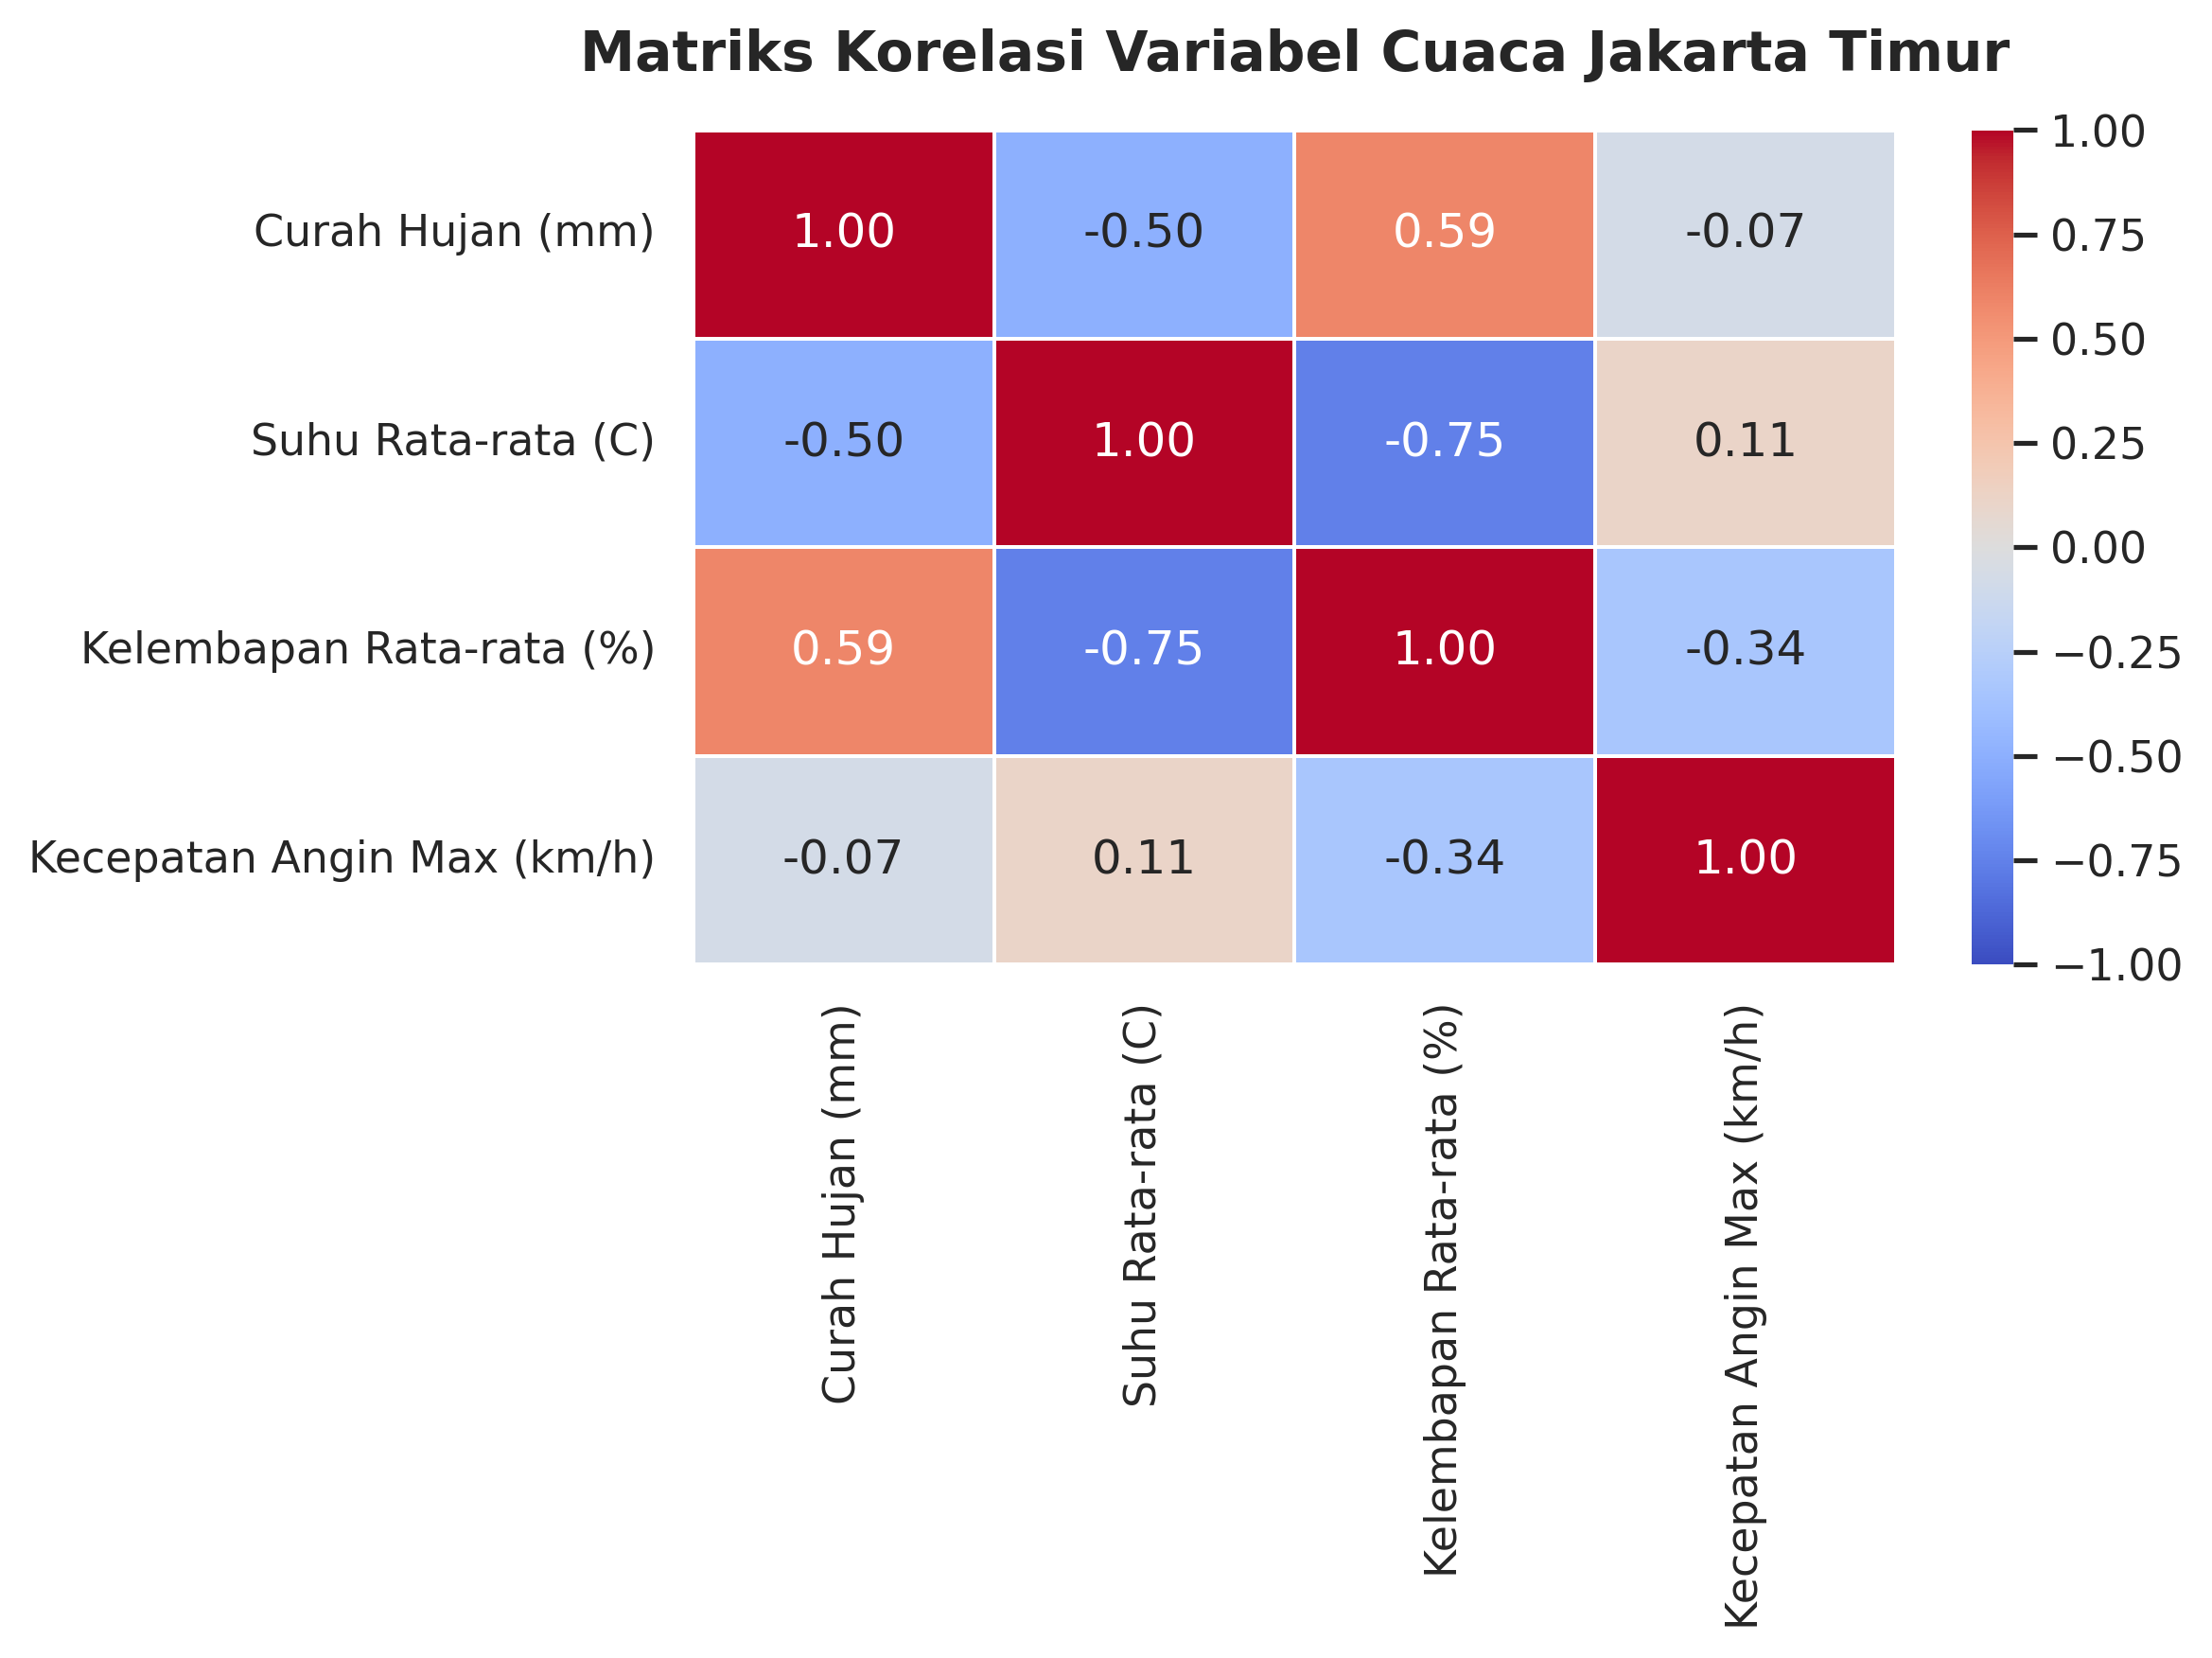

-> Visualisasi Korelasi selesai!


/tmp/ipykernel_1671/2725241260.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Nama Bulan', y='Curah Hujan (mm)', estimator='mean', errorbar=None, palette='Blues_d')


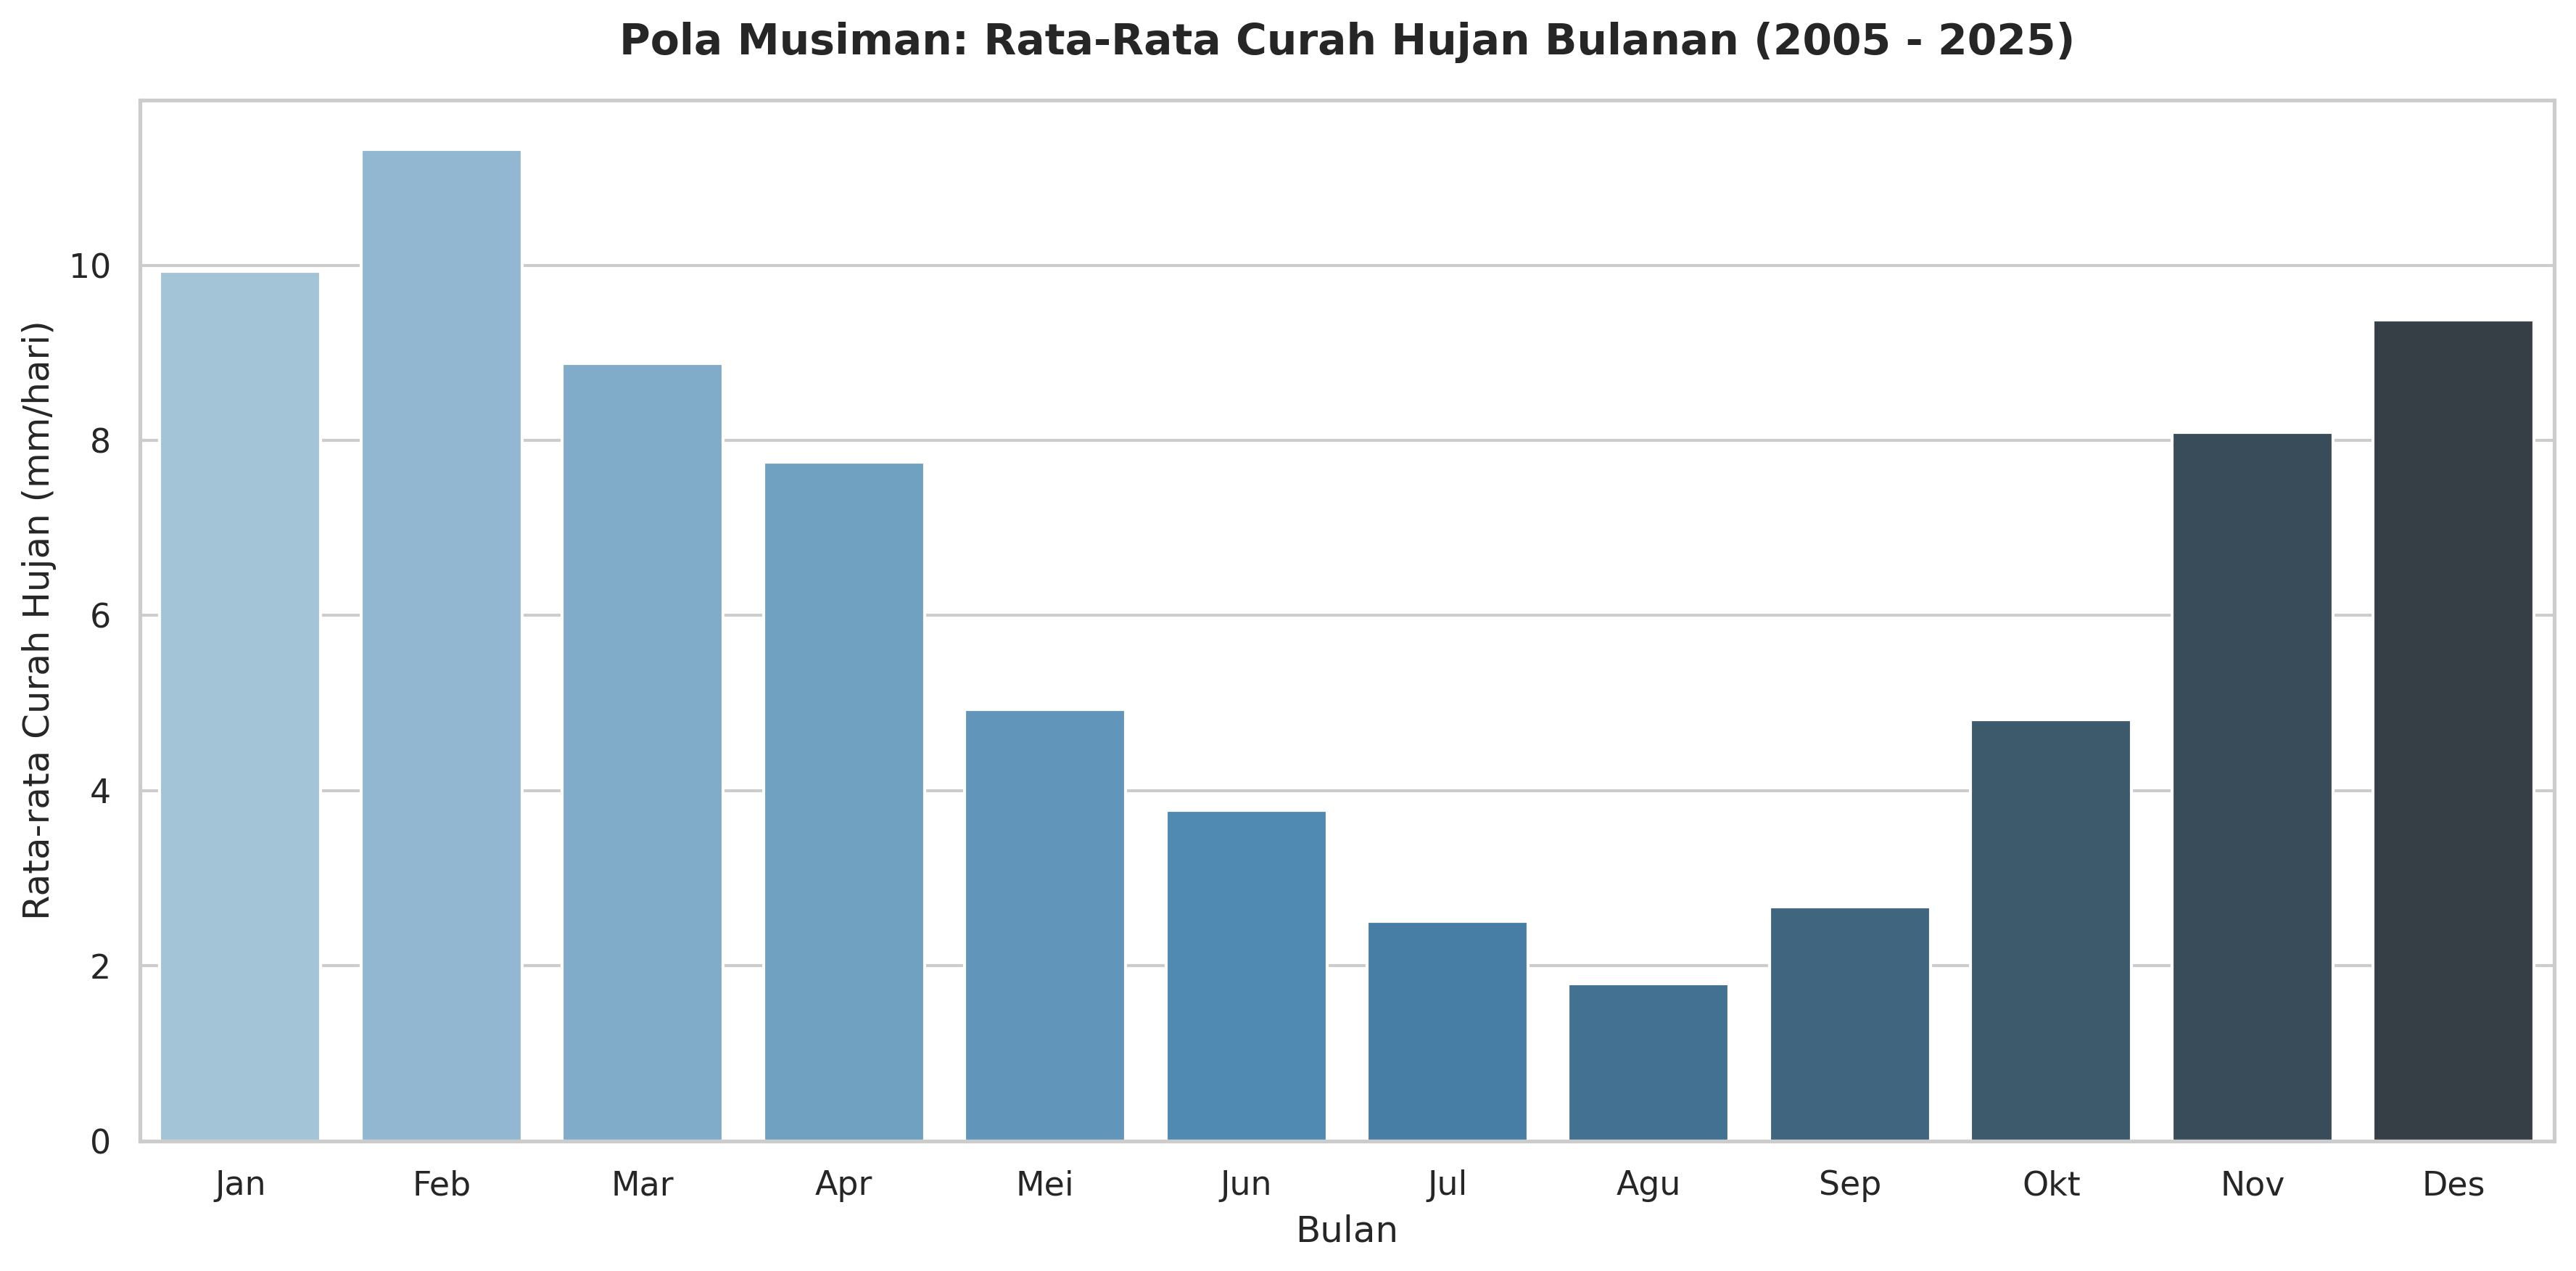

-> Visualisasi Pola Musiman selesai!


/tmp/ipykernel_1671/2725241260.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_hujan_kecamatan, x='Kecamatan', y='Curah Hujan (mm)', palette='viridis')


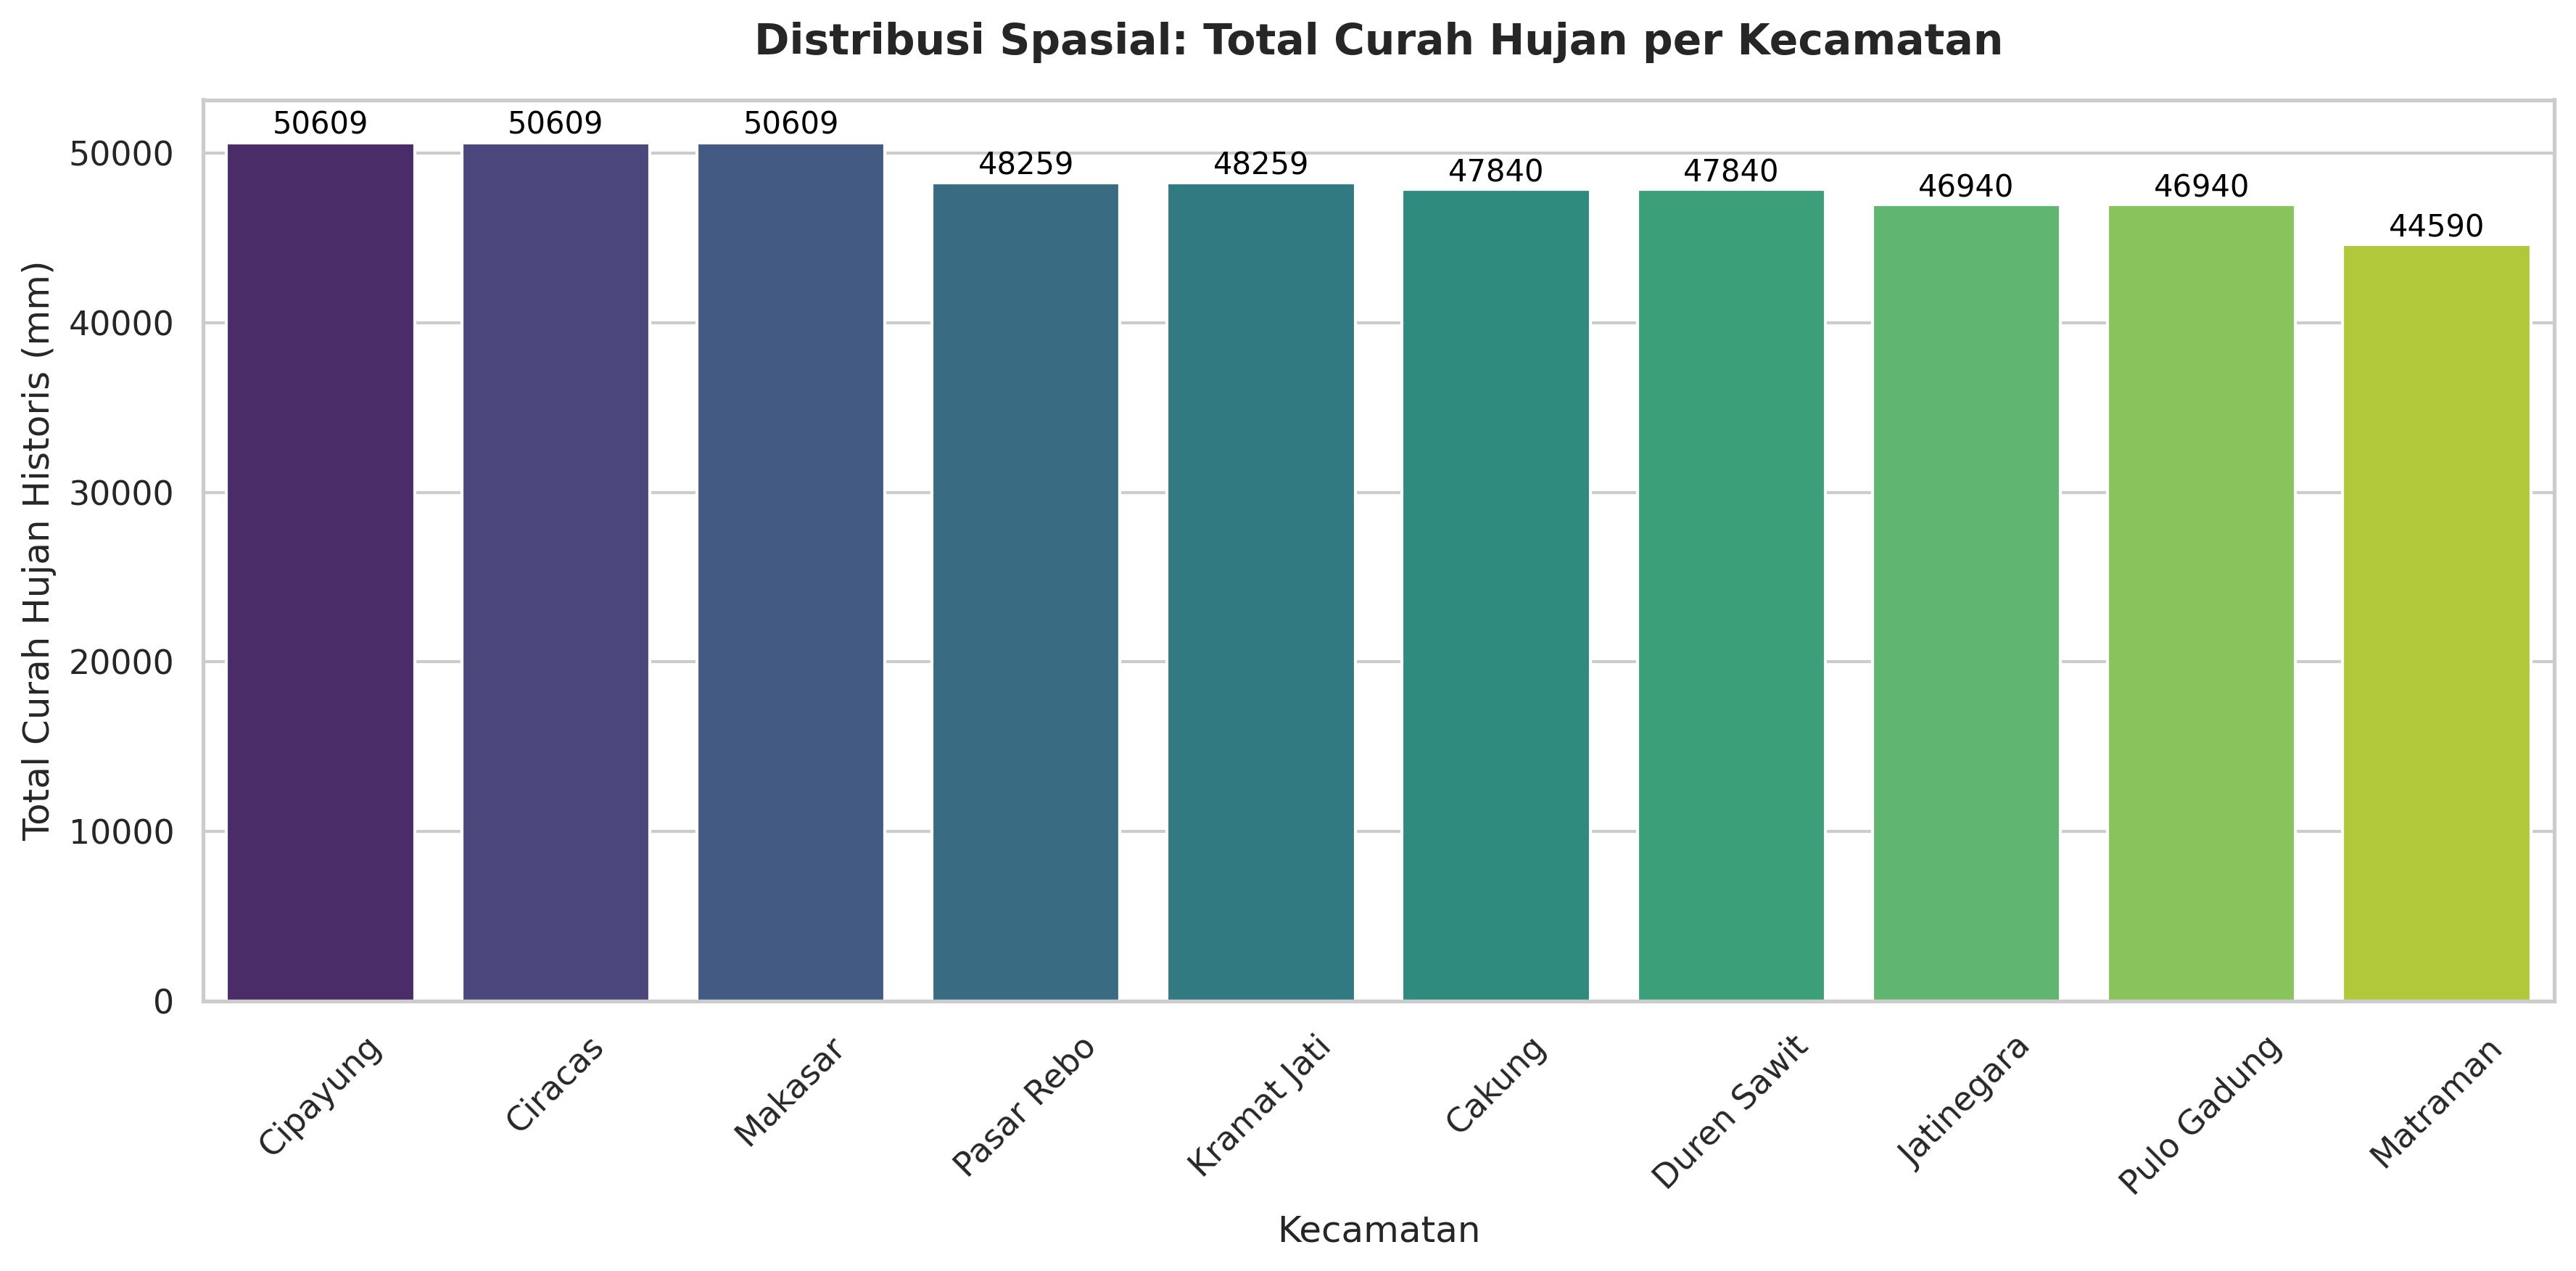

-> Visualisasi Perbandingan Spasial selesai!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PERSIAPAN DATA
print("Membaca dataset...")
df = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df['Bulan'] = df['Tanggal'].dt.month
df['Tahun'] = df['Tanggal'].dt.year

# Set tema visual agar terlihat elegan untuk laporan akademis
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 300 # Resolusi tinggi HD

# ==========================================
# VISUALISASI 1: HEATMAP KORELASI MULTIVARIAT
# ==========================================
plt.figure(figsize=(8, 6))
# Mengambil hanya kolom angka
kolom_angka = ['Curah Hujan (mm)', 'Suhu Rata-rata (C)', 'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)']
matriks_korelasi = df[kolom_angka].corr()

# Membuat heatmap
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Variabel Cuaca Jakarta Timur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('Visual_EDA_1_Korelasi.png')
plt.show()
print("-> Visualisasi Korelasi selesai!")

# ==========================================
# VISUALISASI 2: POLA MUSIMAN (BULANAN)
# ==========================================
plt.figure(figsize=(12, 6))
# Pemetaan angka bulan menjadi nama bulan agar mudah dibaca
nama_bulan = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun',
              7:'Jul', 8:'Agu', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Des'}
df['Nama Bulan'] = df['Bulan'].map(nama_bulan)

# Menggunakan barplot untuk melihat rata-rata curah hujan per bulan
sns.barplot(data=df, x='Nama Bulan', y='Curah Hujan (mm)', estimator='mean', errorbar=None, palette='Blues_d')
plt.title('Pola Musiman: Rata-Rata Curah Hujan Bulanan (2005 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Curah Hujan (mm/hari)', fontsize=12)
plt.tight_layout()
plt.savefig('Visual_EDA_2_Musiman.png')
plt.show()
print("-> Visualisasi Pola Musiman selesai!")

# ==========================================
# VISUALISASI 3: PERBANDINGAN SPASIAL (KECAMATAN)
# ==========================================
plt.figure(figsize=(12, 6))

# Menghitung total curah hujan per kecamatan selama 20 tahun
total_hujan_kecamatan = df.groupby('Kecamatan')['Curah Hujan (mm)'].sum().reset_index()
total_hujan_kecamatan = total_hujan_kecamatan.sort_values('Curah Hujan (mm)', ascending=False)

sns.barplot(data=total_hujan_kecamatan, x='Kecamatan', y='Curah Hujan (mm)', palette='viridis')
plt.title('Distribusi Spasial: Total Curah Hujan per Kecamatan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kecamatan', fontsize=12)
plt.ylabel('Total Curah Hujan Historis (mm)', fontsize=12)
plt.xticks(rotation=45)

# Menambahkan angka di atas setiap bar
for index, row in enumerate(total_hujan_kecamatan['Curah Hujan (mm)']):
    plt.text(index, row + (row*0.01), f"{int(row)}", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.savefig('Visual_EDA_3_Spasial.png')
plt.show()
print("-> Visualisasi Perbandingan Spasial selesai!")

Membaca dataset untuk analisis ketimpangan kelas...


/tmp/ipykernel_1671/871029957.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=distribusi_kelas, x='Kategori Cuaca', y='Total Hari', palette=warna)


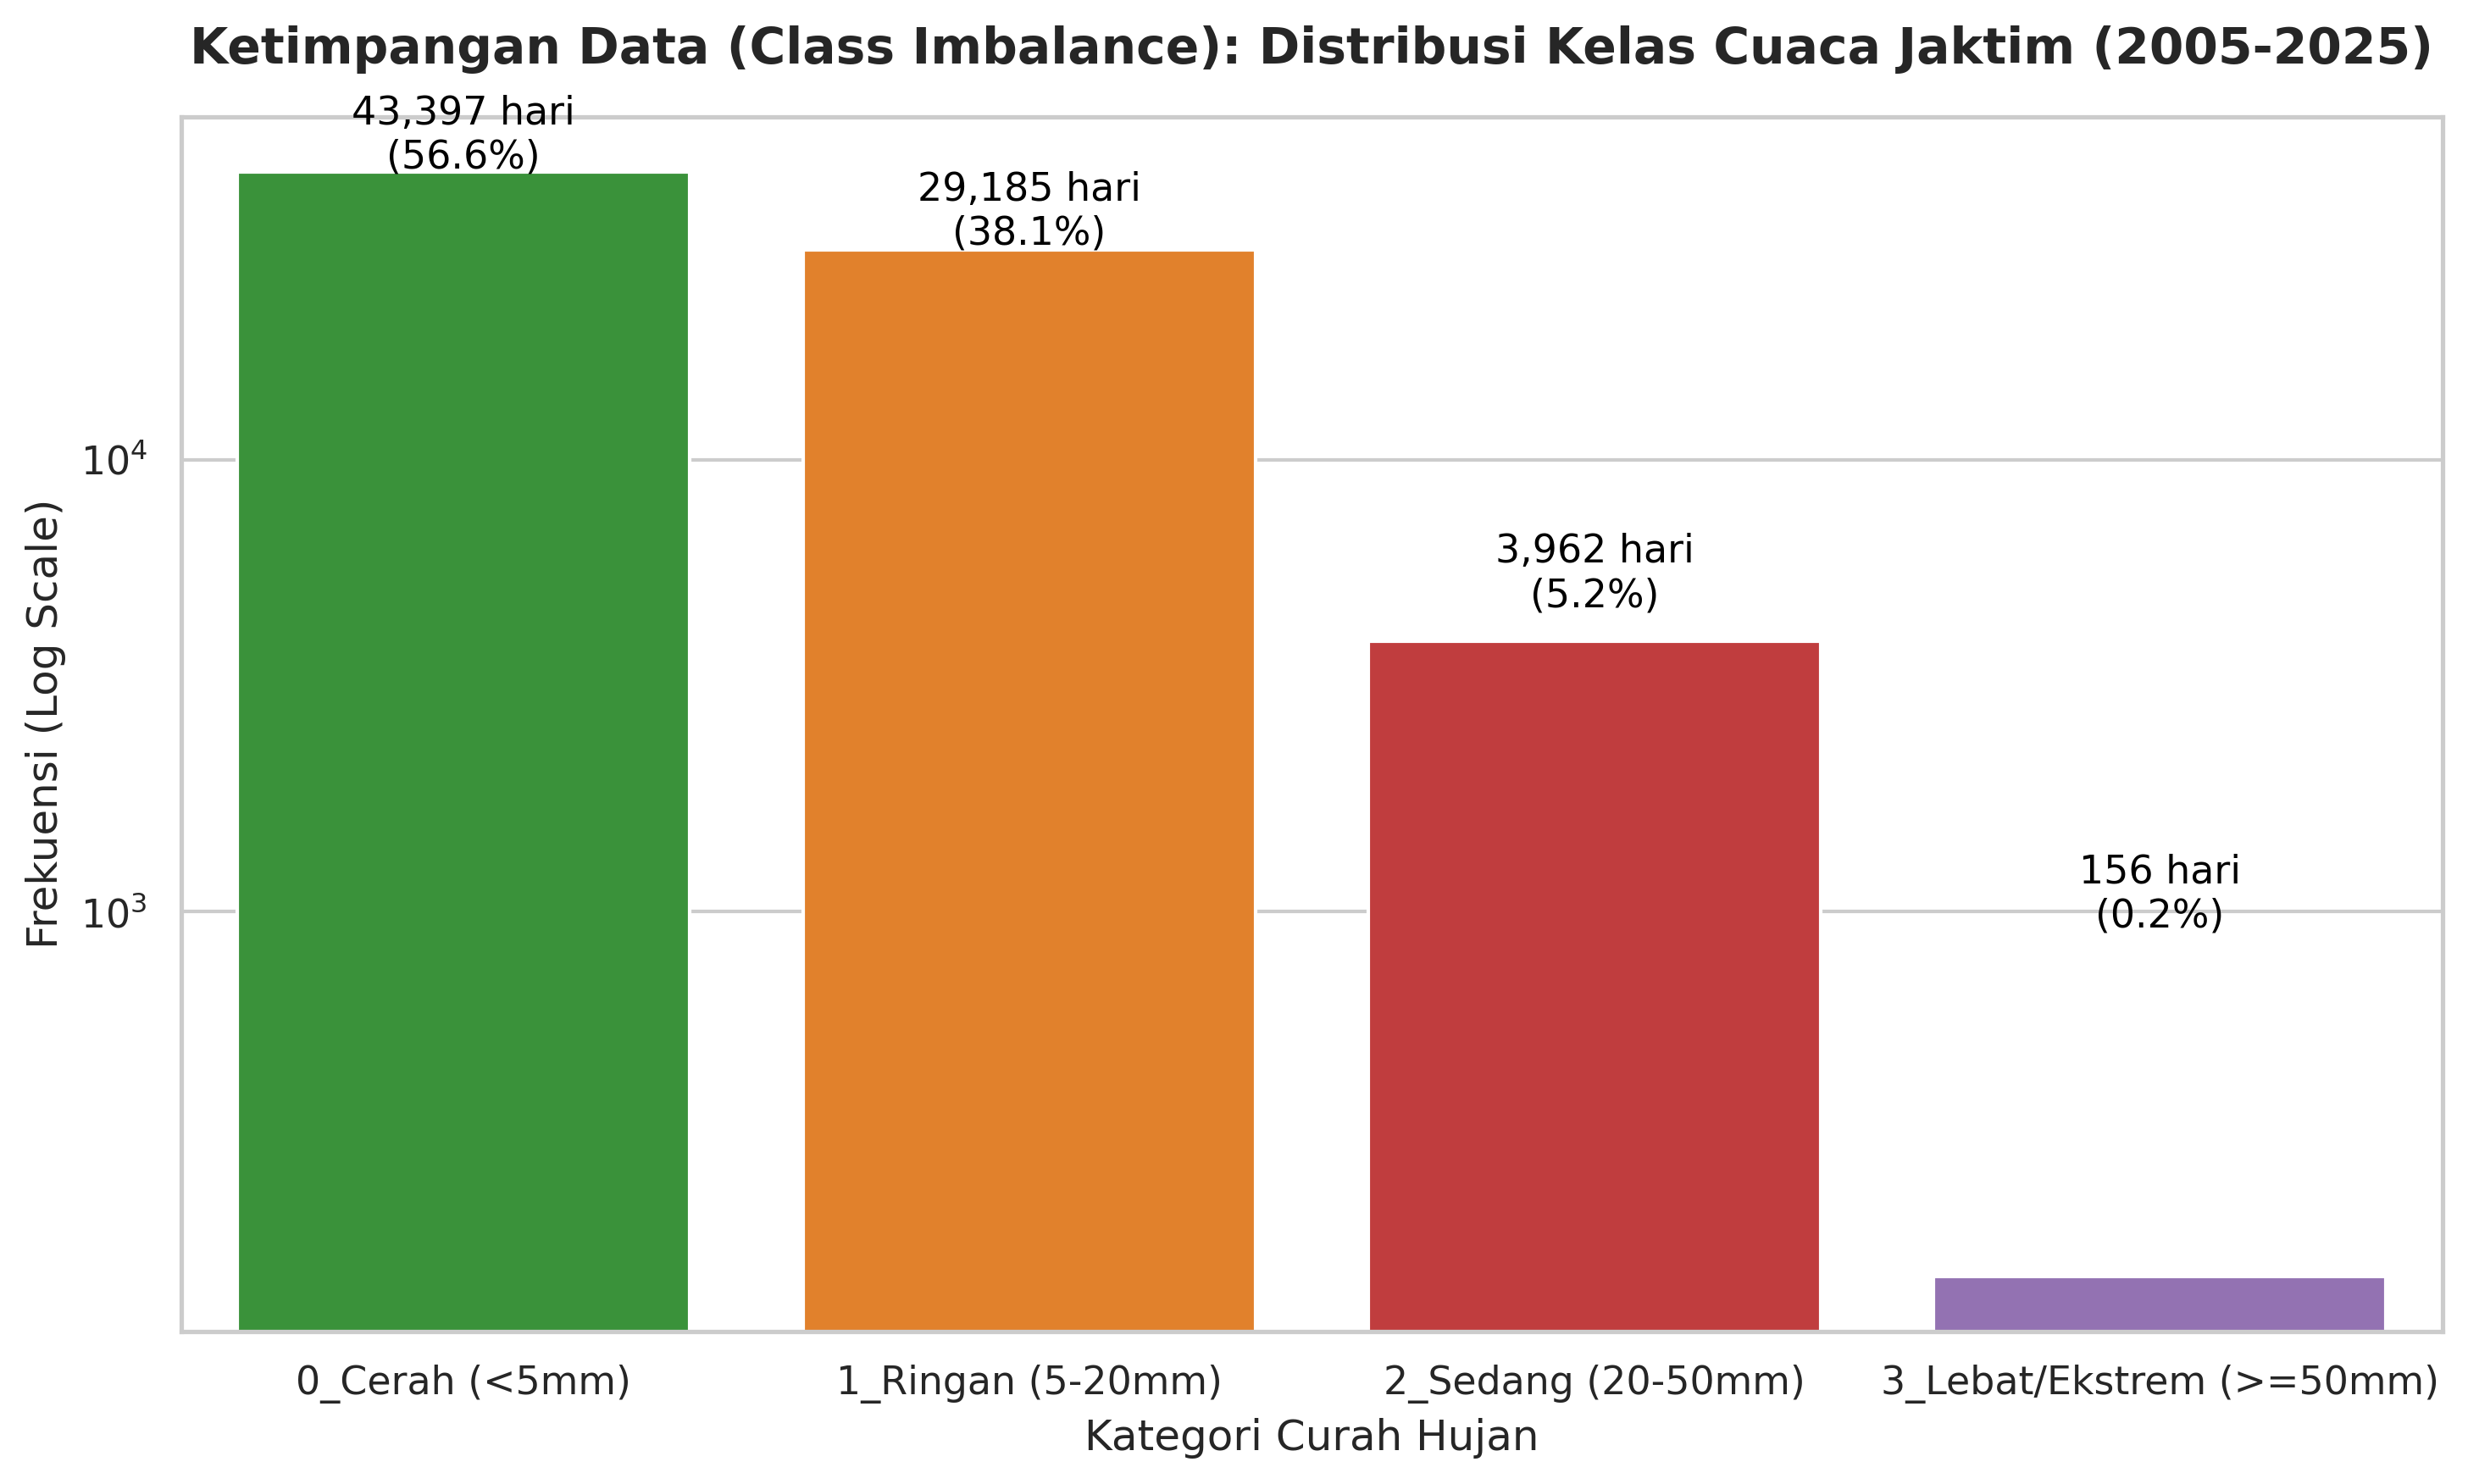


Detail Angka Ketimpangan Data:
          Kategori Cuaca  Total Hari  Persentase
          0_Cerah (<5mm)       43397   56.580183
       1_Ringan (5-20mm)       29185   38.050847
      2_Sedang (20-50mm)        3962    5.165580
3_Lebat/Ekstrem (>=50mm)         156    0.203390


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca Data
print("Membaca dataset untuk analisis ketimpangan kelas...")
df = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')

# 2. Menerapkan Aturan 4 Kelas
def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return '0_Cerah (<5mm)'
    elif 5 <= ch <= 20: return '1_Ringan (5-20mm)'
    elif 20 < ch <= 50: return '2_Sedang (20-50mm)'
    else: return '3_Lebat/Ekstrem (>=50mm)'

df['Kelas Target'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# 3. Menghitung Jumlah Data per Kelas
distribusi_kelas = df['Kelas Target'].value_counts().reset_index()
distribusi_kelas.columns = ['Kategori Cuaca', 'Total Hari']

# Hitung persentase untuk label
total_data = distribusi_kelas['Total Hari'].sum()
distribusi_kelas['Persentase'] = (distribusi_kelas['Total Hari'] / total_data) * 100

# 4. Membuat Visualisasi Bar Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Warna gradasi dari aman ke bahaya
warna = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
ax = sns.barplot(data=distribusi_kelas, x='Kategori Cuaca', y='Total Hari', palette=warna)

plt.title('Ketimpangan Data (Class Imbalance): Distribusi Kelas Cuaca Jaktim (2005-2025)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Curah Hujan', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Hari)', fontsize=12)

# Menambahkan teks angka dan persentase di atas setiap bar
for index, row in distribusi_kelas.iterrows():
    teks = f"{int(row['Total Hari']):,} hari\n({row['Persentase']:.1f}%)"
    plt.text(index, row['Total Hari'] + (total_data*0.01), teks, color='black', ha="center", fontsize=11)

# Skala logaritmik sangat disarankan jika jomplangnya terlalu jauh
plt.yscale('log')
plt.ylabel('Frekuensi (Log Scale)', fontsize=12)

plt.tight_layout()
plt.savefig('Visual_EDA_4_Imbalanced_Data.png', dpi=300)
plt.show()

print("\nDetail Angka Ketimpangan Data:")
print(distribusi_kelas.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import math
import gc # Modul pembersih RAM
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Keras & XGBoost
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA & REKAYASA FITUR BARU
# ==========================================
print("Memproses Data 10 Kecamatan Jakarta Timur...")
# Pastikan nama file sesuai dengan yang ada di Google Colab Anda
df = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df = df.dropna()

# --- REKAYASA FITUR: Rata-rata Hujan 3 Hari Terakhir ---
print("Menambahkan fitur Curah Hujan Kumulatif 3 Harian...")
df = df.sort_values(by=['Kecamatan', 'Tanggal']).reset_index(drop=True)
df['Hujan_3Hari_Kumulatif'] = df.groupby('Kecamatan')['Curah Hujan (mm)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
# --------------------------------------------------------

# Target: 4 Kelas Tingkat Risiko
def klasifikasi_hujan_4_kelas(ch):
    if ch < 5: return 0           # 0: Cerah / Sangat Ringan
    elif 5 <= ch <= 20: return 1  # 1: Ringan
    elif 20 < ch <= 50: return 2  # 2: Sedang
    else: return 3                # 3: Lebat & Ekstrem (>= 50 mm)

df['Label'] = df['Curah Hujan (mm)'].apply(klasifikasi_hujan_4_kelas)

# Cyclical Encoding (Musim)
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)

# One-Hot Encoding (Kartu Nama Kecamatan)
df_dummy = pd.get_dummies(df['Kecamatan'], prefix='Kec')
df = pd.concat([df, df_dummy], axis=1)

# Memasukkan fitur kumulatif baru ke dalam daftar yang akan dipelajari model
fitur_klimat = [
    'Curah Hujan (mm)', 'Hujan_3Hari_Kumulatif', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]
fitur_kecamatan = list(df_dummy.columns)
fitur_lengkap = fitur_klimat + fitur_kecamatan

# Normalisasi
scaler = MinMaxScaler()
df[fitur_lengkap] = scaler.fit_transform(df[fitur_lengkap])

# ==========================================
# 2. MEMBUAT SEQUENCE (DIPERPENDEK JADI 5 HARI)
# ==========================================
# Time steps diubah menjadi 5 agar model tidak bingung dengan data basi
time_steps = 5
print(f"Menyusun Sequence memori {time_steps} hari (Mode Hemat RAM)...")

X_list, y_list = [], []
kecamatan_unik = df['Kecamatan'].unique()

for kec in kecamatan_unik:
    df_kec = df[df['Kecamatan'] == kec].sort_values('Tanggal').reset_index(drop=True)

    # Ubah ke matriks ringan
    nilai_fitur = df_kec[fitur_lengkap].values
    nilai_label = df_kec['Label'].values

    for i in range(len(nilai_fitur) - time_steps):
        X_list.append(nilai_fitur[i : i + time_steps])
        y_list.append(nilai_label[i + time_steps])

# Konversi dan Bersihkan RAM
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

del X_list, y_list, df_kec, df
gc.collect()

print(f"Bentuk input X_train siap: {X_train.shape}")

# ==========================================
# 3. BOBOT KELAS (PENALTI UNTUK KELAS MINORITAS)
# ==========================================
kelas_unik = np.unique(y_train)
bobot_mentah = compute_class_weight('balanced', classes=kelas_unik, y=y_train)
bobot_lembut = [math.sqrt(w) for w in bobot_mentah]
class_weights_dict = dict(zip(kelas_unik, bobot_lembut))

# ==========================================
# 4. TAHAP 1: FEATURE EXTRACTION (Bi-LSTM MULTICLASS)
# ==========================================
print(f"\n--- TAHAP 1: Melatih Bi-LSTM ({len(X_train)} baris) ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.2)(x)

feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
output_layer = Dense(units=4, activation='softmax')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

model_lstm.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nMengekstrak Vektor Fitur Laten dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)
X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: KLASIFIKASI XGBOOST 4 KELAS
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost Spasial (4 Kelas) ---")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    max_depth=6,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)

# ==========================================
# 6. EVALUASI GLOBAL 4 KELAS
# ==========================================
print("\nMelakukan Prediksi pada Data Test...")
y_pred = xgb_model.predict(X_test_features)

nama_kelas = [
    '0_Cerah (<5mm)',
    '1_Ringan (5-20mm)',
    '2_Sedang (20-50mm)',
    '3_Lebat/Ekstrem (>=50mm)'
]

print("\n=======================================================")
print("HASIL EVALUASI SPASIAL HYBRID (OPTIMASI FITUR & WAKTU)   ")
print("=======================================================")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=nama_kelas, zero_division=0))

Memproses Data 10 Kecamatan Jakarta Timur...
Menambahkan fitur Curah Hujan Kumulatif 3 Harian...
Menyusun Sequence memori 5 hari (Mode Hemat RAM)...
Bentuk input X_train siap: (61320, 5, 17)

--- TAHAP 1: Melatih Bi-LSTM (61320 baris) ---
Epoch 1/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.6737 - loss: 0.7924 - val_accuracy: 0.6930 - val_loss: 0.7486 - learning_rate: 0.0010
Epoch 2/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6896 - loss: 0.7601 - val_accuracy: 0.6959 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 3/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6928 - loss: 0.7501 - val_accuracy: 0.6994 - val_loss: 0.7237 - learning_rate: 0.0010
Epoch 4/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6966 - loss: 0.7421 - val_accuracy: 0.6882 - val_loss: 0.8212 - learning_rate: 0.0010
Epoch 5/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6974 - loss: 0.7393 - val_accuracy: 0.7009 - val_loss: 0.7310 - learning_rate

In [10]:
import pandas as pd
import numpy as np
import math
import gc
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras & XGBoost
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (KEMBALI KE BINER 2 KELAS)
# ==========================================
print("Memproses Data 10 Kecamatan Jakarta Timur (Mode Biner)...")
df = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', dayfirst=True)
df = df.dropna()

# Fitur Rekayasa: Hujan Kumulatif 3 Hari
df = df.sort_values(by=['Kecamatan', 'Tanggal']).reset_index(drop=True)
df['Hujan_3Hari_Kumulatif'] = df.groupby('Kecamatan')['Curah Hujan (mm)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# KEMBALI KE TARGET BINER: 0 (Aman) vs 1 (Waspada Badai >= 50mm)
df['Label'] = df['Curah Hujan (mm)'].apply(lambda ch: 1 if ch >= 50 else 0)

# Cyclical & One-Hot Encoding
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)
df_dummy = pd.get_dummies(df['Kecamatan'], prefix='Kec')
df = pd.concat([df, df_dummy], axis=1)

fitur_klimat = [
    'Curah Hujan (mm)', 'Hujan_3Hari_Kumulatif', 'Suhu Rata-rata (C)',
    'Kelembapan Rata-rata (%)', 'Kecepatan Angin Max (km/h)',
    'Bulan_Sin', 'Bulan_Cos'
]
fitur_kecamatan = list(df_dummy.columns)
fitur_lengkap = fitur_klimat + fitur_kecamatan

# Normalisasi
scaler = MinMaxScaler()
df[fitur_lengkap] = scaler.fit_transform(df[fitur_lengkap])

# ==========================================
# 2. MEMBUAT SEQUENCE (5 HARI)
# ==========================================
time_steps = 5
print(f"Menyusun Sequence memori {time_steps} hari...")

X_list, y_list = [], []
for kec in df['Kecamatan'].unique():
    df_kec = df[df['Kecamatan'] == kec].sort_values('Tanggal').reset_index(drop=True)
    nilai_fitur = df_kec[fitur_lengkap].values
    nilai_label = df_kec['Label'].values
    for i in range(len(nilai_fitur) - time_steps):
        X_list.append(nilai_fitur[i : i + time_steps])
        y_list.append(nilai_label[i + time_steps])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

del X_list, y_list, df_kec, df
gc.collect()

# ==========================================
# 3. MENGHITUNG BOBOT IMBALANCE BINER (PENALTI BRUTAL)
# ==========================================
jumlah_aman = np.sum(y_train == 0)
jumlah_waspada = np.sum(y_train == 1)

# Bobot untuk Bi-LSTM (Tanpa akar kuadrat, beri hukuman penuh!)
bobot_0 = 1.0
bobot_1 = (jumlah_aman / jumlah_waspada) * 2.0 # Penalti dilipatgandakan untuk memaksa mesin mikir

class_weights_dict = {0: bobot_0, 1: bobot_1}

# Bobot untuk XGBoost
rasio_imbalance_xgb = jumlah_aman / jumlah_waspada

print(f"Distribusi Training -> Aman: {jumlah_aman}, Waspada: {jumlah_waspada}")
print(f"Bobot Penalti -> Salah tebak Waspada dihukum {bobot_1:.2f} kali lebih berat!")

# ==========================================
# 4. TAHAP 1: FEATURE EXTRACTION (Bi-LSTM BINER)
# ==========================================
print(f"\n--- TAHAP 1: Melatih Bi-LSTM Biner ({len(X_train)} baris) ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.2)(x)

feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
output_layer = Dense(units=1, activation='sigmoid')(feature_layer) # 1 Output Probabilitas

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=0)

model_lstm.fit(
    X_train, y_train, epochs=60, batch_size=64, validation_split=0.2,
    class_weight=class_weights_dict, callbacks=[early_stop, reduce_lr], verbose=1
)

print("\nMengekstrak Vektor Fitur Laten dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)
X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: KLASIFIKASI XGBOOST BINER
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost Spasial (Biner) ---")
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=6,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=rasio_imbalance_xgb, # Hukuman keras jika melewatkan badai
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_features, y_train)

# ==========================================
# 6. EVALUASI AKADEMIS (UNTUK BAB 4 SKRIPSI)
# ==========================================
print("\n=======================================================")
print("      EVALUASI AKADEMIS BINER (AMAN VS WASPADA)        ")
print("=======================================================")
y_pred = xgb_model.predict(X_test_features)
y_prob = xgb_model.predict_proba(X_test_features)[:, 1]
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Aman (<50mm)', 'Waspada (>=50mm)']))

hasil_evaluasi_model = globals().get('hasil_evaluasi_model', {})
hasil_evaluasi_model['multivariat_biner'] = {
    'nama': 'Hybrid Biner Multivariat',
    'y_true': y_test.copy(),
    'y_pred_default': y_pred.copy(),
    'y_prob': y_prob.copy()
}
print("Probabilitas model multivariat berhasil disimpan untuk threshold tuning.")

# ==========================================
# 7. SIMULASI ANTARMUKA WEBGIS (PEMECAHAN 4 WARNA)
# ==========================================
print("\n=======================================================")
print("   SIMULASI APLIKASI WEBGIS (4 TINGKAT PERINGATAN)     ")
print("=======================================================")
# Menyedot persentase probabilitas badai dari XGBoost
probabilitas_badai = xgb_model.predict_proba(X_test_features)[:, 1]

def konversi_ke_warna_webgis(prob):
    if prob < 0.20: return 'Level 1: HIJAU  🟢 (Cerah/Aman)'
    elif 0.20 <= prob < 0.50: return 'Level 2: KUNING 🟡 (Hujan Ringan/Siaga 3)'
    elif 0.50 <= prob < 0.80: return 'Level 3: ORANYE 🟠 (Hujan Sedang/Siaga 2)'
    else: return 'Level 4: MERAH  🔴 (Badai Ekstrem/Siaga 1)'

# Tampilkan 15 sampel prediksi untuk demonstrasi WebGIS
for i in range(15):
    prob = probabilitas_badai[i]
    warna = konversi_ke_warna_webgis(prob)
    aktual = "Waspada Badai" if y_test[i] == 1 else "Aman"

    print(f"Sampel Uji {i+1:02d} | Keyakinan Badai: {prob*100:05.2f}% -> {warna}")

Memproses Data 10 Kecamatan Jakarta Timur (Mode Biner)...
Menyusun Sequence memori 5 hari...
Distribusi Training -> Aman: 61196, Waspada: 124
Bobot Penalti -> Salah tebak Waspada dihukum 987.03 kali lebih berat!

--- TAHAP 1: Melatih Bi-LSTM Biner (61320 baris) ---
Epoch 1/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.1584 - loss: 2.1485 - val_accuracy: 0.1192 - val_loss: 0.9934 - learning_rate: 0.0010
Epoch 2/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.2302 - loss: 1.7981 - val_accuracy: 0.1333 - val_loss: 1.4557 - learning_rate: 0.0010
Epoch 3/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2183 - loss: 1.9906 - val_accuracy: 0.6027 - val_loss: 0.7425 - learning_rate: 0.0010
Epoch 4/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4148 - loss: 1.8759 - val_accuracy: 0.4640 - val_loss: 0.7904 - learning_rate: 0.0010
Epoch 5/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4242 - loss: 1.7276 - val_accuracy: 0.3219 - val_l

In [2]:
import joblib

print("Memulai proses penyimpanan model (Exporting)...")

# 1. Menyimpan Model Bi-LSTM (Ekstraktor Fitur)
# Disimpan dalam format .h5 (Hierarchical Data Format) standar Keras/TensorFlow
model_lstm.save('model_bilstm_jaktim.h5')
print("✅ Model Bi-LSTM berhasil disimpan sebagai 'model_bilstm_jaktim.h5'")

# 2. Menyimpan Model XGBoost (Klasifikator Spasial)
# Disimpan dalam format .pkl (Pickle) standar library Python
joblib.dump(xgb_model, 'model_xgboost_jaktim.pkl')
print("✅ Model XGBoost berhasil disimpan sebagai 'model_xgboost_jaktim.pkl'")

# 3. Menyimpan Scaler (PENTING untuk preprocessing data WebGIS nanti)
joblib.dump(scaler, 'scaler_jaktim.pkl')
print("✅ Scaler berhasil disimpan sebagai 'scaler_jaktim.pkl'")

# 4. Menyimpan Daftar Kolom Fitur (Opsional tapi sangat membantu)
# Agar nanti di backend kita ingat urutan kolom datanya tidak boleh terbalik
daftar_fitur = fitur_lengkap
joblib.dump(daftar_fitur, 'daftar_kolom_fitur.pkl')
print("✅ Daftar kolom fitur berhasil disimpan.")

print("\n=======================================================")
print("SIAP DEPLOY! Silakan download keempat file tersebut dari panel kiri Google Colab.")
print("=======================================================")

Memulai proses penyimpanan model (Exporting)...
✅ Model Bi-LSTM berhasil disimpan sebagai 'model_bilstm_jaktim.h5'
✅ Model XGBoost berhasil disimpan sebagai 'model_xgboost_jaktim.pkl'
✅ Scaler berhasil disimpan sebagai 'scaler_jaktim.pkl'
✅ Daftar kolom fitur berhasil disimpan.

SIAP DEPLOY! Silakan download keempat file tersebut dari panel kiri Google Colab.


In [3]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

print("1. MEMUAT KEMBALI MODEL & SCALER DARI PENYIMPANAN...")
# Load semua file yang sudah diekspor sebelumnya
lstm_loaded = load_model('model_bilstm_jaktim.h5')
xgb_loaded = joblib.load('model_xgboost_jaktim.pkl')
scaler_loaded = joblib.load('scaler_jaktim.pkl')
daftar_fitur_loaded = joblib.load('daftar_kolom_fitur.pkl')

print("✅ Semua komponen AI berhasil dimuat!\n")

print("2. MENYIAPKAN DATA UJI COBA (SIMULASI WEBGIS)...")
# Kita pura-pura server menerima data cuaca mentah dari BMKG/Open-Meteo
# Mari kita ambil data asli dari dataset Anda untuk pengujian
df_mentah = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')
df_mentah['Tanggal'] = pd.to_datetime(df_mentah['Tanggal'], format='%d/%m/%Y', dayfirst=True)

# Skenario: Kita ingin menebak cuaca di Kecamatan Duren Sawit
kecamatan_target = 'Duren Sawit'

# Ambil data historis khusus Duren Sawit dan urutkan
df_target = df_mentah[df_mentah['Kecamatan'] == kecamatan_target].sort_values('Tanggal').reset_index(drop=True)

# Lakukan rekayasa fitur yang sama persis seperti saat training!
df_target['Hujan_3Hari_Kumulatif'] = df_target['Curah Hujan (mm)'].rolling(window=3, min_periods=1).mean()
df_target['Bulan'] = df_target['Tanggal'].dt.month
df_target['Bulan_Sin'] = np.sin(2 * np.pi * df_target['Bulan'] / 12)
df_target['Bulan_Cos'] = np.cos(2 * np.pi * df_target['Bulan'] / 12)

# One-Hot Encoding untuk Kartu Nama
# Karena data mentah mungkin tidak punya 10 kecamatan sekaligus di skenario ini,
# kita buat kolom kecamatannya secara manual agar pas 17 fitur
for fitur in daftar_fitur_loaded:
    if fitur.startswith('Kec_'):
        # Jika kolom itu adalah Kec_Duren Sawit, isi 1. Sisanya isi 0.
        df_target[fitur] = 1 if fitur == f'Kec_{kecamatan_target}' else 0

# Kita potong HANYA 5 HARI TERAKHIR untuk menebak hari ke-6
df_5_hari = df_target.tail(5).copy()

print(f"Data 5 Hari Terakhir di {kecamatan_target}:")
display(df_5_hari[['Tanggal', 'Curah Hujan (mm)', 'Suhu Rata-rata (C)', 'Kelembapan Rata-rata (%)']])

# 3. PREPROCESSING MENGGUNAKAN SCALER YANG DISIMPAN
data_siap_scale = df_5_hari[daftar_fitur_loaded]
data_scaled = scaler_loaded.transform(data_siap_scale)

# Bentuk ulang (Reshape) menjadi format matriks 3D untuk Bi-LSTM (1 sampel, 5 time steps, 17 fitur)
X_inference = np.array([data_scaled])

print("\n3. MEMULAI PREDIKSI HYBRID...")
# Tahap A: Ekstrak Fitur Laten pakai Bi-LSTM
# Kita harus membuat model ekstraktor khusus seperti saat training
ekstraktor_loaded = Model(inputs=lstm_loaded.input, outputs=lstm_loaded.get_layer('feature_layer').output)
fitur_laten_baru = ekstraktor_loaded.predict(X_inference, verbose=0)

# Tahap B: Tebak Probabilitas pakai XGBoost
probabilitas = xgb_loaded.predict_proba(fitur_laten_baru)[0, 1]

# 4. KELUARAN UNTUK PETA WEBGIS
def konversi_ke_warna(prob):
    if prob < 0.20: return 'Level 1: HIJAU  🟢 (Cerah/Aman)'
    elif 0.20 <= prob < 0.50: return 'Level 2: KUNING 🟡 (Hujan Ringan/Siaga 3)'
    elif 0.50 <= prob < 0.80: return 'Level 3: ORANYE 🟠 (Hujan Sedang/Siaga 2)'
    else: return 'Level 4: MERAH  🔴 (Badai Ekstrem/Siaga 1)'

warna_status = konversi_ke_warna(probabilitas)

print("=======================================================")
print(f" HASIL PREDIKSI SISTEM UNTUK {kecamatan_target.upper()}")
print("=======================================================")
print(f"Probabilitas Badai : {probabilitas * 100:.2f}%")
print(f"Status Peta WebGIS : {warna_status}")
print("=======================================================")

1. MEMUAT KEMBALI MODEL & SCALER DARI PENYIMPANAN...
✅ Semua komponen AI berhasil dimuat!

2. MENYIAPKAN DATA UJI COBA (SIMULASI WEBGIS)...
Data 5 Hari Terakhir di Duren Sawit:


,Tanggal,Curah Hujan (mm),Suhu Rata-rata (C),Kelembapan Rata-rata (%)
7665,2025-12-27,2.6,28.0,77
7666,2025-12-28,12.6,27.3,82
7667,2025-12-29,3.4,27.3,81
7668,2025-12-30,37.6,26.7,84
7669,2025-12-31,33.2,25.1,90



3. MEMULAI PREDIKSI HYBRID...
 HASIL PREDIKSI SISTEM UNTUK DUREN SAWIT
Probabilitas Badai : 2.54%
Status Peta WebGIS : Level 1: HIJAU  🟢 (Cerah/Aman)


In [4]:
import pandas as pd

print("Membaca dataset utama...")
# Ganti nama file jika Anda menggunakan versi yang '(1)'
df = pd.read_csv('Master_Data_Spasial_Jaktim.csv', sep=';')

# Memilih hanya kolom yang relevan
# Tanggal dan Kecamatan tetap dipertahankan agar data memiliki konteks
df_curah_hujan = df[['Tanggal', 'Kecamatan', 'Curah Hujan (mm)']]

print("Mengekspor data...")
# Menyimpan ke file CSV baru
nama_file_ekspor = 'Ekspor_Data_Curah_Hujan.csv'
df_curah_hujan.to_csv(nama_file_ekspor, index=False, sep=';')

print(f"✅ Berhasil! Data telah dipotong dan diekspor menjadi '{nama_file_ekspor}'")

# Menampilkan 5 data pertama sebagai pratinjau (preview)
print("\nPratinjau Data Baru:")
display(df_curah_hujan.head())

Membaca dataset utama...
Mengekspor data...
✅ Berhasil! Data telah dipotong dan diekspor menjadi 'Ekspor_Data_Curah_Hujan.csv'

Pratinjau Data Baru:


,Tanggal,Kecamatan,Curah Hujan (mm)
0,01/01/2005,Cakung,6.9
1,01/01/2005,Cipayung,6.9
2,01/01/2005,Ciracas,6.9
3,01/01/2005,Duren Sawit,6.9
4,01/01/2005,Jatinegara,6.9


In [9]:
import pandas as pd
import numpy as np
import gc 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Keras & XGBoost
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

# ==========================================
# 1. PERSIAPAN DATA (MODE UNIVARIAT: FOKUS CURAH HUJAN)
# ==========================================
print("Memproses Data Histori Curah Hujan...")
df = pd.read_csv('Ekspor_Data_Curah_Hujan.csv', sep=';')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y')
df = df.dropna()

# Rekayasa Fitur: Hujan Kumulatif 3 Hari
df = df.sort_values(by=['Kecamatan', 'Tanggal']).reset_index(drop=True)
df['Hujan_3Hari_Kumulatif'] = df.groupby('Kecamatan')['Curah Hujan (mm)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Target Biner (Aman vs Waspada Badai >= 50mm)
df['Label'] = df['Curah Hujan (mm)'].apply(lambda ch: 1 if ch >= 50 else 0)

# Penanda Waktu & Ruang (Wajib untuk WebGIS Spasiotemporal)
df['Bulan'] = df['Tanggal'].dt.month
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan'] / 12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan'] / 12)
df_dummy = pd.get_dummies(df['Kecamatan'], prefix='Kec')
df = pd.concat([df, df_dummy], axis=1)

# FITUR DIPANGKAS! Suhu, Kelembapan, dan Angin dihilangkan sama sekali.
fitur_klimat = [
    'Curah Hujan (mm)', 'Hujan_3Hari_Kumulatif', 
    'Bulan_Sin', 'Bulan_Cos'
]
fitur_kecamatan = list(df_dummy.columns) 
fitur_lengkap = fitur_klimat + fitur_kecamatan

# Normalisasi 
scaler = MinMaxScaler()
df[fitur_lengkap] = scaler.fit_transform(df[fitur_lengkap])

# ==========================================
# 2. MEMBUAT SEQUENCE (5 HARI)
# ==========================================
time_steps = 5 
print(f"Menyusun Sequence memori {time_steps} hari...")

X_list, y_list = [], []
for kec in df['Kecamatan'].unique():
    df_kec = df[df['Kecamatan'] == kec].sort_values('Tanggal').reset_index(drop=True)
    nilai_fitur = df_kec[fitur_lengkap].values
    nilai_label = df_kec['Label'].values
    for i in range(len(nilai_fitur) - time_steps):
        X_list.append(nilai_fitur[i : i + time_steps])
        y_list.append(nilai_label[i + time_steps])

X = np.array(X_list, dtype=np.float32) 
y = np.array(y_list, dtype=np.int8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

del X_list, y_list, df_kec, df
gc.collect() 

# ==========================================
# 3. BOBOT IMBALANCE (PENALTI BRUTAL)
# ==========================================
jumlah_aman = np.sum(y_train == 0)
jumlah_waspada = np.sum(y_train == 1)

# Hukuman keras untuk Bi-LSTM agar tidak malas
bobot_0 = 1.0
bobot_1 = (jumlah_aman / jumlah_waspada) * 2.0 
class_weights_dict = {0: bobot_0, 1: bobot_1}
rasio_imbalance_xgb = jumlah_aman / jumlah_waspada

print(f"\nDistribusi Training -> Aman: {jumlah_aman}, Waspada: {jumlah_waspada}")
print(f"Beban Penalti Kelas Waspada: {bobot_1:.2f}x lipat")

# ==========================================
# 4. TAHAP 1: FEATURE EXTRACTION (Bi-LSTM UNIVARIAT)
# ==========================================
print(f"\n--- TAHAP 1: Melatih Bi-LSTM Univariat ({len(X_train)} baris) ---")
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Bidirectional(LSTM(units=64, return_sequences=True))(input_layer)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(units=32, return_sequences=False))(x)
x = Dropout(0.2)(x)

feature_layer = Dense(units=16, activation='relu', name='feature_layer')(x)
output_layer = Dense(units=1, activation='sigmoid')(feature_layer)

model_lstm = Model(inputs=input_layer, outputs=output_layer)
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=0)

model_lstm.fit(
    X_train, y_train, epochs=60, batch_size=64, validation_split=0.2,
    class_weight=class_weights_dict, callbacks=[early_stop, reduce_lr], verbose=1
)

print("\nMengekstrak Vektor Fitur Laten dari Bi-LSTM...")
feature_extractor = Model(inputs=model_lstm.input, outputs=model_lstm.get_layer('feature_layer').output)
X_train_features = feature_extractor.predict(X_train, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

# ==========================================
# 5. TAHAP 2: KLASIFIKASI XGBOOST
# ==========================================
print("\n--- TAHAP 2: Melatih XGBoost Univariat ---")
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', 
    max_depth=6,              
    learning_rate=0.05,       
    n_estimators=300,         
    scale_pos_weight=rasio_imbalance_xgb, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_features, y_train)

# ==========================================
# 6. EVALUASI
# ==========================================
print("\n=======================================================")
print("  EVALUASI MODEL UNIVARIAT (HANYA CURAH HUJAN)         ")
print("=======================================================")
y_pred = xgb_model.predict(X_test_features)
y_prob = xgb_model.predict_proba(X_test_features)[:, 1]
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Aman (<50mm)', 'Waspada (>=50mm)']))

hasil_evaluasi_model = globals().get('hasil_evaluasi_model', {})
hasil_evaluasi_model['univariat_biner'] = {
    'nama': 'Hybrid Biner Univariat',
    'y_true': y_test.copy(),
    'y_pred_default': y_pred.copy(),
    'y_prob': y_prob.copy()
}
print("Probabilitas model univariat berhasil disimpan untuk threshold tuning.")

Memproses Data Histori Curah Hujan...
Menyusun Sequence memori 5 hari...

Distribusi Training -> Aman: 61196, Waspada: 124
Beban Penalti Kelas Waspada: 987.03x lipat

--- TAHAP 1: Melatih Bi-LSTM Univariat (61320 baris) ---
Epoch 1/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.2875 - loss: 2.0814 - val_accuracy: 0.0590 - val_loss: 1.3655 - learning_rate: 0.0010
Epoch 2/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2127 - loss: 1.7466 - val_accuracy: 0.2578 - val_loss: 1.2982 - learning_rate: 0.0010
Epoch 3/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3654 - loss: 1.7093 - val_accuracy: 0.2910 - val_loss: 1.0963 - learning_rate: 0.0010
Epoch 4/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3581 - loss: 1.8121 - val_accuracy: 0.2005 - val_loss: 1.0942 - learning_rate: 0.0010
Epoch 5/60
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2809 - loss: 1.8260 - val_accuracy: 0.4312 - val_loss: 1.0180 - learning_rate: 0.0010
Epoch 6/60
767/

## Perbandingan Jujur Model Univariat vs Multivariat

Cell ini dipakai untuk membandingkan model dari sudut pandang deteksi kelas `Waspada`, bukan hanya `accuracy`.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score

if 'hasil_evaluasi_model' not in globals():
    raise RuntimeError('Jalankan dulu cell model biner multivariat dan univariat agar hasil evaluasi terbaru tersimpan.')

kunci_model = ['multivariat_biner', 'univariat_biner']
kunci_hilang = [kunci for kunci in kunci_model if kunci not in hasil_evaluasi_model]
if kunci_hilang:
    raise RuntimeError(f'Data evaluasi belum lengkap: {kunci_hilang}. Jalankan ulang cell model yang sesuai.')

baris_hasil = []
y_true_baseline = hasil_evaluasi_model['multivariat_biner']['y_true']
support_aman = int(np.sum(y_true_baseline == 0))
support_waspada = int(np.sum(y_true_baseline == 1))

for kunci in kunci_model:
    info_model = hasil_evaluasi_model[kunci]
    y_true = info_model['y_true']
    y_pred = info_model['y_pred_default']

    baris_hasil.append({
        'Model': info_model['nama'],
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Recall_Waspada': recall_score(y_true, y_pred, zero_division=0),
        'Precision_Waspada': precision_score(y_true, y_pred, zero_division=0),
        'F1_Waspada': f1_score(y_true, y_pred, zero_division=0),
        'Waspada_Terdeteksi': int(np.sum((y_true == 1) & (y_pred == 1))),
        'Total_Waspada': int(np.sum(y_true == 1))
    })

baseline_pred = np.zeros_like(y_true_baseline)
baris_hasil.append({
    'Model': 'Baseline: Tebak Semua Aman',
    'Accuracy': accuracy_score(y_true_baseline, baseline_pred),
    'Balanced_Accuracy': balanced_accuracy_score(y_true_baseline, baseline_pred),
    'Recall_Waspada': recall_score(y_true_baseline, baseline_pred, zero_division=0),
    'Precision_Waspada': precision_score(y_true_baseline, baseline_pred, zero_division=0),
    'F1_Waspada': f1_score(y_true_baseline, baseline_pred, zero_division=0),
    'Waspada_Terdeteksi': int(np.sum((y_true_baseline == 1) & (baseline_pred == 1))),
    'Total_Waspada': support_waspada
})

df_perbandingan_model = pd.DataFrame(baris_hasil)
df_perbandingan_tampil = df_perbandingan_model.copy()
for kolom in ['Accuracy', 'Balanced_Accuracy', 'Recall_Waspada', 'Precision_Waspada', 'F1_Waspada']:
    df_perbandingan_tampil[kolom] = (df_perbandingan_tampil[kolom] * 100).map(lambda nilai: f'{nilai:.2f}%')

print('Perbandingan model pada data uji biner (otomatis dari hasil terbaru):')
display(
    df_perbandingan_tampil[[
        'Model', 'Accuracy', 'Balanced_Accuracy',
        'Recall_Waspada', 'F1_Waspada',
        'Waspada_Terdeteksi', 'Total_Waspada'
    ]]
)

terbaik_akurasi = df_perbandingan_model.sort_values(by='Accuracy', ascending=False).iloc[0]
terbaik_deteksi = df_perbandingan_model.sort_values(
    by=['Recall_Waspada', 'F1_Waspada', 'Balanced_Accuracy'],
    ascending=False
).iloc[0]

print('\nRingkasan:')
print(f"- Accuracy tertinggi: {terbaik_akurasi['Model']} ({terbaik_akurasi['Accuracy']:.4f})")
print(f"- Model paling berguna untuk mendeteksi kelas Waspada: {terbaik_deteksi['Model']}")
print(f"- {terbaik_deteksi['Model']} menangkap {int(terbaik_deteksi['Waspada_Terdeteksi'])} dari {int(terbaik_deteksi['Total_Waspada'])} kasus Waspada pada threshold default.")

if terbaik_deteksi['Recall_Waspada'] < 0.30:
    print('- Kesimpulan awal: threshold default masih terlalu konservatif; perlu threshold tuning agar recall Waspada naik.')


## Threshold Tuning dan Precision-Recall Curve

Jalankan ulang cell model biner multivariat dan univariat terlebih dahulu, lalu jalankan cell di bawah ini.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)

if 'hasil_evaluasi_model' not in globals():
    raise RuntimeError('Jalankan dulu cell model biner multivariat dan univariat agar probabilitas tersimpan.')

kunci_wajib = ['multivariat_biner', 'univariat_biner']
kunci_hilang = [kunci for kunci in kunci_wajib if kunci not in hasil_evaluasi_model]
if kunci_hilang:
    raise RuntimeError(f'Data evaluasi ini belum lengkap: {kunci_hilang}. Jalankan ulang cell model yang sesuai.')

def sweep_threshold(info_model, threshold_list=None):
    if threshold_list is None:
        threshold_list = np.arange(0.05, 1.00, 0.05)

    y_true = info_model['y_true']
    y_prob = info_model['y_prob']
    rows = []

    for threshold in threshold_list:
        y_pred_threshold = (y_prob >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred_threshold)
        tn, fp, fn, tp = cm.ravel()

        rows.append({
            'Model': info_model['nama'],
            'Threshold': round(float(threshold), 2),
            'Precision_Waspada': precision_score(y_true, y_pred_threshold, zero_division=0),
            'Recall_Waspada': recall_score(y_true, y_pred_threshold, zero_division=0),
            'F1_Waspada': f1_score(y_true, y_pred_threshold, zero_division=0),
            'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred_threshold),
            'Alarm_Palsu': int(fp),
            'Waspada_Lolos': int(fn),
            'Waspada_Terdeteksi': int(tp)
        })

    return pd.DataFrame(rows)

semua_hasil_threshold = []
ringkasan_threshold = []

for kunci in kunci_wajib:
    info_model = hasil_evaluasi_model[kunci]
    df_threshold = sweep_threshold(info_model)
    semua_hasil_threshold.append(df_threshold)

    baris_default = df_threshold.loc[np.isclose(df_threshold['Threshold'], 0.50)].iloc[0]
    baris_f1_terbaik = df_threshold.sort_values(
        by=['F1_Waspada', 'Recall_Waspada', 'Balanced_Accuracy'],
        ascending=False
    ).iloc[0]
    baris_recall_terbaik = df_threshold.sort_values(
        by=['Recall_Waspada', 'Precision_Waspada', 'F1_Waspada'],
        ascending=False
    ).iloc[0]

    ringkasan_threshold.append({
        'Model': info_model['nama'],
        'Threshold_Default': baris_default['Threshold'],
        'Recall_Default': baris_default['Recall_Waspada'],
        'F1_Default': baris_default['F1_Waspada'],
        'Threshold_F1_Terbaik': baris_f1_terbaik['Threshold'],
        'Recall_pada_F1_Terbaik': baris_f1_terbaik['Recall_Waspada'],
        'F1_Terbaik': baris_f1_terbaik['F1_Waspada'],
        'Threshold_Recall_Terbaik': baris_recall_terbaik['Threshold'],
        'Recall_Terbaik': baris_recall_terbaik['Recall_Waspada'],
        'Precision_pada_Recall_Terbaik': baris_recall_terbaik['Precision_Waspada']
    })

df_threshold_semua = pd.concat(semua_hasil_threshold, ignore_index=True)
df_ringkasan_threshold = pd.DataFrame(ringkasan_threshold)

df_ringkasan_tampil = df_ringkasan_threshold.copy()
for kolom in [
    'Recall_Default', 'F1_Default', 'Recall_pada_F1_Terbaik',
    'F1_Terbaik', 'Recall_Terbaik', 'Precision_pada_Recall_Terbaik'
]:
    df_ringkasan_tampil[kolom] = (df_ringkasan_tampil[kolom] * 100).map(lambda nilai: f'{nilai:.2f}%')

print('Ringkasan threshold tuning:')
display(df_ringkasan_tampil)

print('Detail sweep threshold:')
display(df_threshold_semua)


Ringkasan threshold tuning:


,Model,Threshold_Default,Recall_Default,F1_Default,Threshold_F1_Terbaik,Recall_pada_F1_Terbaik,F1_Terbaik,Threshold_Recall_Terbaik,Recall_Terbaik,Precision_pada_Recall_Terbaik
0,Hybrid Biner Multivariat,0.5,6.25%,1.58%,0.35,18.75%,2.88%,0.05,34.38%,0.62%
1,Hybrid Biner Univariat,0.5,3.12%,0.99%,0.60,3.12%,1.39%,0.05,18.75%,0.32%


Detail sweep threshold:


,Model,Threshold,Precision_Waspada,Recall_Waspada,F1_Waspada,Balanced_Accuracy,Alarm_Palsu,Waspada_Lolos,Waspada_Terdeteksi
0,Hybrid Biner Multivariat,0.05,0.006246,0.34375,0.012270,0.614678,1750,21,11
1,Hybrid Biner Multivariat,0.10,0.008052,0.31250,0.015699,0.615983,1232,22,10
2,Hybrid Biner Multivariat,0.15,0.008466,0.25000,0.016377,0.594375,937,24,8
3,Hybrid Biner Multivariat,0.20,0.009447,0.21875,0.018111,0.585385,734,25,7
4,Hybrid Biner Multivariat,0.25,0.011382,0.21875,0.021638,0.589503,608,25,7
5,Hybrid Biner Multivariat,0.30,0.012245,0.18750,0.022989,0.577931,484,26,6
6,Hybrid Biner Multivariat,0.35,0.015584,0.18750,0.028777,0.581363,379,26,6
7,Hybrid Biner Multivariat,0.40,0.015674,0.15625,0.028490,0.567862,314,27,5
8,Hybrid Biner Multivariat,0.45,0.015152,0.12500,0.027027,0.554002,260,28,4
9,Hybrid Biner Multivariat,0.50,0.009050,0.06250,0.015810,0.524092,219,30,2


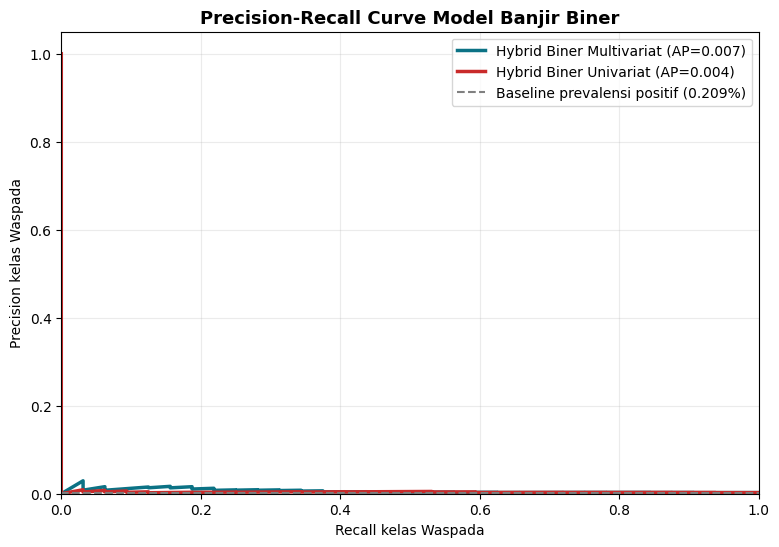

Interpretasi cepat: semakin luas area kurva dan semakin tinggi nilai AP, semakin baik model membedakan kelas Waspada.


In [14]:
plt.figure(figsize=(9, 6))

for kunci, warna in [('multivariat_biner', '#0b7285'), ('univariat_biner', '#c92a2a')]:
    info_model = hasil_evaluasi_model[kunci]
    y_true = info_model['y_true']
    y_prob = info_model['y_prob']

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    average_precision = average_precision_score(y_true, y_prob)
    plt.plot(recall_curve, precision_curve, linewidth=2.5, color=warna,
             label=f"{info_model['nama']} (AP={average_precision:.3f})")

baseline_positif = hasil_evaluasi_model['multivariat_biner']['y_true'].mean()
plt.axhline(baseline_positif, linestyle='--', color='gray',
            label=f'Baseline prevalensi positif ({baseline_positif:.3%})')

plt.title('Precision-Recall Curve Model Banjir Biner', fontsize=13, fontweight='bold')
plt.xlabel('Recall kelas Waspada')
plt.ylabel('Precision kelas Waspada')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

print('Interpretasi cepat: semakin luas area kurva dan semakin tinggi nilai AP, semakin baik model membedakan kelas Waspada.')


## Narasi Ringkas Hasil Tuning

Cell ini merangkum threshold yang paling masuk akal untuk dibahas di Bab 4.


In [15]:
if 'df_ringkasan_threshold' not in globals() or 'df_threshold_semua' not in globals():
    raise RuntimeError('Jalankan dulu cell threshold tuning agar tabel ringkas tersedia.')

kandidat_narasi = []
for nama_model in df_threshold_semua['Model'].unique():
    df_model = df_threshold_semua[df_threshold_semua['Model'] == nama_model].copy()
    df_model = df_model.sort_values(by='Threshold')

    threshold_default = df_model.loc[np.isclose(df_model['Threshold'], 0.50)].iloc[0]
    threshold_f1 = df_model.sort_values(
        by=['F1_Waspada', 'Recall_Waspada', 'Balanced_Accuracy'],
        ascending=False
    ).iloc[0]
    kandidat_recall_layak = df_model[df_model['Recall_Waspada'] >= 0.15].copy()
    if not kandidat_recall_layak.empty:
        threshold_rekomendasi = kandidat_recall_layak.sort_values(
            by=['Alarm_Palsu', 'F1_Waspada'],
            ascending=[True, False]
        ).iloc[0]
    else:
        threshold_rekomendasi = threshold_f1

    kandidat_narasi.append({
        'Model': nama_model,
        'Recall_Default': threshold_default['Recall_Waspada'],
        'F1_Default': threshold_default['F1_Waspada'],
        'Threshold_Rekomendasi': threshold_rekomendasi['Threshold'],
        'Recall_Rekomendasi': threshold_rekomendasi['Recall_Waspada'],
        'F1_Rekomendasi': threshold_rekomendasi['F1_Waspada'],
        'Alarm_Palsu_Rekomendasi': int(threshold_rekomendasi['Alarm_Palsu']),
        'Waspada_Terdeteksi_Rekomendasi': int(threshold_rekomendasi['Waspada_Terdeteksi']),
        'Waspada_Lolos_Rekomendasi': int(threshold_rekomendasi['Waspada_Lolos'])
    })

df_narasi = pd.DataFrame(kandidat_narasi)
df_narasi_tampil = df_narasi.copy()
for kolom in ['Recall_Default', 'F1_Default', 'Recall_Rekomendasi', 'F1_Rekomendasi']:
    df_narasi_tampil[kolom] = (df_narasi_tampil[kolom] * 100).map(lambda nilai: f'{nilai:.2f}%')

display(df_narasi_tampil)

model_terbaik = df_narasi.sort_values(
    by=['Recall_Rekomendasi', 'F1_Rekomendasi'],
    ascending=False
).iloc[0]

print('Narasi singkat hasil tuning:')
for _, row in df_narasi.iterrows():
    print(
        f"- {row['Model']}: threshold default 0.50 memberi recall {row['Recall_Default']:.2%}. "
        f"Threshold rekomendasi {row['Threshold_Rekomendasi']:.2f} menaikkan recall menjadi {row['Recall_Rekomendasi']:.2%} "
        f"dengan {row['Alarm_Palsu_Rekomendasi']} alarm palsu."
    )

print(
    f"- Model yang paling layak dibahas lebih lanjut adalah {model_terbaik['Model']}, "
    f"karena pada threshold rekomendasi ia memberi recall {model_terbaik['Recall_Rekomendasi']:.2%} "
    f"dan mendeteksi {model_terbaik['Waspada_Terdeteksi_Rekomendasi']} kasus Waspada."
)
print('- Catatan: precision masih rendah, jadi model ini lebih cocok disebut sistem pendukung kewaspadaan awal daripada alarm final.')


,Model,Recall_Default,F1_Default,Threshold_Rekomendasi,Recall_Rekomendasi,F1_Rekomendasi,Alarm_Palsu_Rekomendasi,Waspada_Terdeteksi_Rekomendasi,Waspada_Lolos_Rekomendasi
0,Hybrid Biner Multivariat,6.25%,1.58%,0.40,15.62%,2.85%,314,5,27
1,Hybrid Biner Univariat,3.12%,0.99%,0.05,18.75%,0.64%,1849,6,26


Narasi singkat hasil tuning:
- Hybrid Biner Multivariat: threshold default 0.50 memberi recall 6.25%. Threshold rekomendasi 0.40 menaikkan recall menjadi 15.62% dengan 314 alarm palsu.
- Hybrid Biner Univariat: threshold default 0.50 memberi recall 3.12%. Threshold rekomendasi 0.05 menaikkan recall menjadi 18.75% dengan 1849 alarm palsu.
- Model yang paling layak dibahas lebih lanjut adalah Hybrid Biner Univariat, karena pada threshold rekomendasi ia memberi recall 18.75% dan mendeteksi 6 kasus Waspada.
- Catatan: precision masih rendah, jadi model ini lebih cocok disebut sistem pendukung kewaspadaan awal daripada alarm final.
